# Exploration — Lumina & Co (notebook personnel de Kémil)

Ce notebook est séparé de `notebook_TP1_...` et `notebook_TP2_...` pour ne pas perturber le travail des partenaires de groupe.

**Point de départ :** en observant les données, on a remarqué qu'une seule campagne — celle du printemps (`Spring_Launch`) — dépasse le million d'euros de revenu, alors que les autres non. Objectif : comprendre pourquoi, et voir ce qui est réplicable sur les autres campagnes.

**Deuxième volet :** creuser les profils clients au-delà du RFM brut, en croisant la segmentation comportementale avec les données zero-party (préférences déclarées, âge, situation de vie, densité urbaine) pour voir si ça permet d'affiner l'expérience client.


## 1. Le pic du printemps est-il un effet saisonnier récurrent ?

On recalcule le chiffre d'affaires réel par saison, année par année, à partir de `transactions_clean.csv` (donnée déjà nettoyée en TP1, avec le fix du filtre `code_atypique`).

In [ ]:
tx = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])

tx["annee"]  = tx["invoice_date"].dt.year
tx["mois"]   = tx["invoice_date"].dt.month
tx["saison"] = tx["mois"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Ete", 7: "Ete", 8: "Ete",
    9: "Automne", 10: "Automne", 11: "Automne"
})

print("====== CA par annee x saison ======")
ca_annee_saison = tx.groupby(["annee", "saison"])["line_total"].sum().unstack().round(0)
print(ca_annee_saison)

print("\n====== CA total par saison (toutes annees confondues) ======")
print(tx.groupby("saison")["line_total"].sum().sort_values(ascending=False).round(0))


====== CA par annee x saison ======
saison    Automne        Ete      Hiver  Printemps
annee                                             
2022      17669.0     5180.0    12890.0     2260.0
2023     210884.0   133472.0   120501.0    71867.0
2024    2902837.0  2007399.0  1283575.0   528058.0
2025    3144198.0  3488312.0  3110648.0  3924023.0
2026          NaN  1354019.0  2146118.0  4176421.0

====== CA total par saison (toutes annees confondues) ======
saison
Printemps    8702629.0
Ete          6988381.0
Hiver        6673733.0
Automne      6275589.0
Name: line_total, dtype: float64


**Lecture :** en 2022, 2023 et 2024, le printemps est en réalité la saison la **plus faible** de l'année (ex: 2024 → 528k€ contre 1,28M-2,9M pour les autres saisons). Ce n'est qu'en 2025 qu'il dépasse à peine l'été, et en 2026 la comparaison est biaisée car l'été et l'automne n'ont que quelques mois de données.

**Conclusion : il n'y a pas d'effet saisonnier naturel qui favorise le printemps.** Le pic de 2026 n'est pas une récurrence historique.

## 2. Ce que dit `campaigns.csv` : budget vs efficacité

Cette table (et `touchpoints.csv`) existent dans le projet mais n'avaient jamais été exploitées en TP1/TP2. Elles contiennent la performance agrégée par campagne (budget, revenu, taux de conversion, ROAS).

In [ ]:
campaigns = pd.read_csv("Lumina & Co - CRM/campaigns.csv")

campaigns["budget_relatif"] = (campaigns["total_cost"] / campaigns["total_cost"].min()).round(2)

print("====== Campagnes triees par revenu ======")
cols = ["campaign_name", "total_cost", "revenue", "conversion_rate", "roas", "cpa", "primary_channel"]
print(campaigns.sort_values("revenue", ascending=False)[cols].to_string(index=False))

print("\n====== Budget relatif (vs la campagne la moins chere) ======")
print(campaigns[["campaign_name", "total_cost", "budget_relatif"]].sort_values("total_cost", ascending=False).to_string(index=False))

print("\n====== Simulation : et si Winter_Promo avait eu le budget de Spring_Launch ? ======")
winter = campaigns[campaigns["campaign_name"] == "Winter_Promo"].iloc[0]
spring = campaigns[campaigns["campaign_name"] == "Spring_Launch"].iloc[0]
revenu_hypothetique = spring["total_cost"] * winter["roas"]
print(f"Budget Spring_Launch applique au ROAS de Winter_Promo : {revenu_hypothetique:,.0f} EUR")
print(f"Revenu reel de Spring_Launch                          : {spring['revenue']:,.0f} EUR")


====== Campagnes triees par revenu ======
 campaign_name  total_cost    revenue  conversion_rate  roas   cpa primary_channel
 Spring_Launch 374813.3262 1686555.27           0.7655  4.50 18.40         display
  Black_Friday 205749.4125  957170.87           0.6971  4.65 10.96         display
     Valentine 247465.9644  853184.79           0.5857  3.45 16.34         display
Back_to_School 159256.4075  725541.50           0.5168  4.56 12.07          social
  Winter_Promo 133949.0025  716632.64           0.5527  5.35  9.45         display
   Summer_Sale 226774.1597  621009.60           0.5010  2.74 17.84         display

====== Budget relatif (vs la campagne la moins chere) ======
 campaign_name  total_cost  budget_relatif
 Spring_Launch 374813.3262            2.80
     Valentine 247465.9644            1.85
   Summer_Sale 226774.1597            1.69
  Black_Friday 205749.4125            1.54
Back_to_School 159256.4075            1.19
  Winter_Promo 133949.0025            1.00

====== Simula

**Lecture :** `Spring_Launch` a un budget de 374 813€ — **2,8× le budget de la campagne la moins chère** (`Winter_Promo`, 133 949€). C'est le plus gros budget de toutes les campagnes.

Son ROAS (retour par euro dépensé) est de 4,50 — ce n'est même pas le meilleur : `Winter_Promo` fait 5,35 avec un budget presque 3× plus petit.

**Conclusion : le printemps ne dépasse le million pas grâce à un effet magique, mais parce qu'on lui a alloué beaucoup plus de budget — et pas forcément au canal le plus efficace.** À budget égal, `Winter_Promo` aurait généré davantage de revenu que `Spring_Launch`.

**Piste actionnable pour "réitérer" :** ne pas copier le printemps, mais réallouer une partie du budget vers les campagnes les plus efficientes (ROAS le plus élevé), et comprendre pourquoi leur mix canal/timing convertit mieux par euro dépensé — à explorer avec `touchpoints.csv` (canaux, position dans le parcours) dans une prochaine étape.

## 3. Segmentation clients par règles (au-delà des 3 cas extrêmes)

La consigne TP2 demande de dépasser les segments "555 / 111 / à risque" (qui ne couvrent que les cas extrêmes) avec des règles par plage justifiées, pour arriver à 5-8 segments nommés couvrant toute la base.

In [ ]:
customers = pd.read_csv("clean_data/customers_clean.csv")

# Scores RFM par quintiles (1 a 5)
customers["score_R"] = pd.qcut(customers["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
customers["score_F"] = pd.qcut(customers["n_orders"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
customers["score_M"] = pd.qcut(customers["total_spent"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segmenter(row):
    r, f, m = row["score_R"], row["score_F"], row["score_M"]
    if r >= 4 and f >= 4 and m >= 4:            return "Champions"
    if r >= 4 and f <= 2:                       return "Nouveaux prometteurs"
    if r <= 2 and f >= 4 and m >= 4:            return "A risque (forte valeur, inactifs)"
    if r <= 2 and f <= 2 and m <= 2:            return "Perdus"
    if r >= 3 and f >= 3 and m >= 3:            return "Fideles"
    if r <= 2:                                  return "Hibernants"
    return "Clients moyens"

customers["segment"] = customers.apply(segmenter, axis=1)

print("====== Repartition des segments ======")
rep = customers["segment"].value_counts()
print(rep)
print((rep / len(customers) * 100).round(1).astype(str) + " %")

print("\n====== Part du CA par segment ======")
ca_seg = customers.groupby("segment")["total_spent"].sum().sort_values(ascending=False)
print((ca_seg / customers["total_spent"].sum() * 100).round(1).astype(str) + " %")


====== Repartition des segments ======
segment
Champions                            10003
Perdus                                9625
Fideles                               9457
Hibernants                            8192
Clients moyens                        6228
Nouveaux prometteurs                  4089
A risque (forte valeur, inactifs)     2035
Name: count, dtype: int64
segment
Champions                            20.2 %
Perdus                               19.4 %
Fideles                              19.1 %
Hibernants                           16.5 %
Clients moyens                       12.5 %
Nouveaux prometteurs                  8.2 %
A risque (forte valeur, inactifs)     4.1 %
Name: count, dtype: str

====== Part du CA par segment ======
segment
Champions                            53.0 %
Fideles                              22.3 %
Hibernants                            9.0 %
A risque (forte valeur, inactifs)     7.0 %
Clients moyens                        3.0 %
Nouveaux prometteurs

**Règles utilisées** (documentées, à adapter/justifier dans le rendu final) :
- **Champions** : récent, fréquent, gros montant (R≥4, F≥4, M≥4)
- **Nouveaux prometteurs** : récent mais peu de commandes (R≥4, F≤2)
- **À risque** : forte valeur historique mais inactif depuis longtemps (R≤2, F≥4, M≥4)
- **Perdus** : tout est bas (R≤2, F≤2, M≤2)
- **Fidèles** : scores moyens-hauts sur les trois dimensions (R≥3, F≥3, M≥3)
- **Hibernants** : peu récent, sans forte valeur ni forte fréquence (R≤2, reste)
- **Clients moyens** : tout ce qui ne rentre dans aucune règle ci-dessus

**Lecture :** 7 segments, 100% de la base couverte. Champions = 20,2% des clients mais 53% du CA (Pareto confirmé). Perdus = 19,4% des clients pour seulement 2,8% du CA. À risque = seulement 4,1% des clients mais 7% du CA — prioritaires pour une action de réactivation ciblée.

## 4. Le comportement d'achat (RFM) est-il lié au profil déclaré (zero-party) ?

"Pour aller plus loin" du TP2 : croiser un segment RFM avec un champ zero-party pour voir si ça révèle un profil plus précis qu'avec le RFM seul.

In [ ]:
zp_cols = ["declared_preference", "age_bracket", "life_stage", "urban_density"]

print("====== Taux de remplissage zero-party PAR SEGMENT (%) ======")
taux = customers.groupby("segment")[zp_cols].apply(lambda g: g.notna().mean() * 100).round(1)
print(taux)

print("\n====== declared_preference : repartition PAR SEGMENT, parmi ceux qui ont repondu (%) ======")
sub = customers[customers["declared_preference"].notna()]
crosstab = (pd.crosstab(sub["segment"], sub["declared_preference"], normalize="index") * 100).round(1)
print(crosstab)


====== Taux de remplissage zero-party PAR SEGMENT (%) ======
                                   declared_preference  ...  urban_density
segment                                                 ...               
A risque (forte valeur, inactifs)                 37.5  ...           21.3
Champions                                         38.0  ...           20.1
Clients moyens                                    38.6  ...           19.6
Fideles                                           37.8  ...           19.7
Hibernants                                        37.5  ...           19.5
Nouveaux prometteurs                              37.9  ...           19.1
Perdus                                            39.0  ...           19.9

[7 rows x 4 columns]

====== declared_preference : repartition PAR SEGMENT, parmi ceux qui ont repondu (%) ======
declared_preference                Anti-imperfections  ...  Sans parfum
segment                                                ...             
A ris

**Lecture :** le taux de réponse aux enquêtes (37-39% pour la préférence, 42-43% pour l'âge, ~20-23% pour la situation de vie et la densité urbaine) est quasi identique quel que soit le segment — un Champion ne répond pas plus ou moins qu'un client Perdu. La répartition des préférences déclarées est également plate sur tous les segments (écarts de 1 à 3 points = bruit statistique, pas un signal).

**Conclusion : dans cette base, le comportement d'achat (RFM) et le profil déclaré (zero-party) sont statistiquement indépendants.** Croiser les deux n'affine pas la segmentation — mais le zero-party reste utile *au niveau individuel* : personnaliser le message ou le produit recommandé à un client qui a répondu à l'enquête, indépendamment de son segment de valeur.


## Synthèse

1. Le pic de revenu du printemps 2026 n'est pas un effet saisonnier récurrent (il était même historiquement la saison la plus faible) — c'est un effet de budget marketing (2,8× le budget de la campagne la moins chère), pas d'efficacité (ROAS pas le meilleur).
2. Piste d'action : réallouer du budget vers les campagnes à meilleur ROAS (`Winter_Promo`) plutôt que de chercher à "reproduire" le printemps.
3. La segmentation RFM par règles couvre 100% de la base en 7 segments actionnables, avec une forte concentration de valeur sur les Champions (53% du CA pour 20% des clients).
4. Le croisement RFM × zero-party ne révèle pas de profil démographique/préférence distinctif par segment — ces données restent utiles pour la personnalisation individuelle, pas pour la segmentation.

**Prochaine étape possible :** creuser `touchpoints.csv` (canal, position dans le parcours, coût par touchpoint) pour comprendre precisement *pourquoi* `Winter_Promo` convertit mieux par euro dépensé que les autres campagnes.


## 5. Quels profils reviennent (ou pas) selon la saison et l'année ?

On reprend la segmentation de la section 3 et on regarde, saison par saison puis année par année, quels segments dominent — et surtout, qui ne suit pas un pattern stable.

In [ ]:
# recharge et resegmente (identique a la section 3)
customers = pd.read_csv("clean_data/customers_clean.csv")
customers["score_R"] = pd.qcut(customers["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
customers["score_F"] = pd.qcut(customers["n_orders"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
customers["score_M"] = pd.qcut(customers["total_spent"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segmenter(row):
    r, f, m = row["score_R"], row["score_F"], row["score_M"]
    if r >= 4 and f >= 4 and m >= 4:            return "Champions"
    if r >= 4 and f <= 2:                       return "Nouveaux prometteurs"
    if r <= 2 and f >= 4 and m >= 4:            return "A risque"
    if r <= 2 and f <= 2 and m <= 2:            return "Perdus"
    if r >= 3 and f >= 3 and m >= 3:            return "Fideles"
    if r <= 2:                                  return "Hibernants"
    return "Clients moyens"

customers["segment"] = customers.apply(segmenter, axis=1)

tx = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])
tx["annee"]  = tx["invoice_date"].dt.year
tx["mois"]   = tx["invoice_date"].dt.month
tx["saison"] = tx["mois"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Ete", 7: "Ete", 8: "Ete",
    9: "Automne", 10: "Automne", 11: "Automne"
})
tx = tx.merge(customers[["customer_id", "segment"]], on="customer_id", how="left")
print("Segmentation et jointure OK —", tx["segment"].isna().sum(), "lignes sans segment")


Segmentation et jointure OK — 9 lignes sans segment


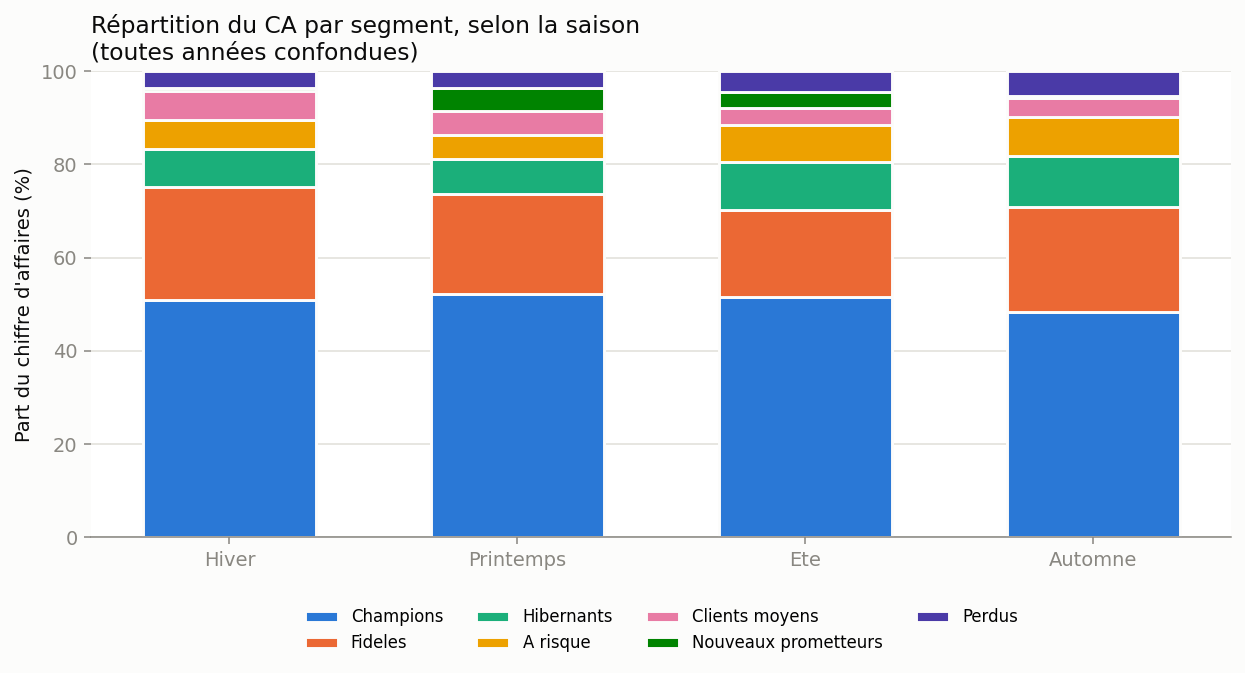

In [ ]:
saisons_ordre = ["Hiver", "Printemps", "Ete", "Automne"]
segs_ordre = ["Champions", "Fideles", "Hibernants", "A risque", "Clients moyens", "Nouveaux prometteurs", "Perdus"]
PAL = {
    "Champions": "#2a78d6", "Fideles": "#eb6834", "Hibernants": "#1baf7a",
    "A risque": "#eda100", "Clients moyens": "#e87ba4",
    "Nouveaux prometteurs": "#008300", "Perdus": "#4a3aa7",
}

ca_seg_saison = tx.groupby(["saison", "segment"])["line_total"].sum().unstack(fill_value=0)
ca_seg_saison = ca_seg_saison.reindex(index=saisons_ordre, columns=segs_ordre)
ca_pct = ca_seg_saison.div(ca_seg_saison.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = pd.Series(0.0, index=ca_pct.index)
for seg in segs_ordre:
    vals = ca_pct[seg]
    ax.bar(ca_pct.index, vals, bottom=bottom, width=0.6, color=PAL[seg], label=seg,
           edgecolor="white", linewidth=1.5)
    bottom += vals
ax.set_ylabel("Part du chiffre d'affaires (%)")
ax.set_title("Répartition du CA par segment, selon la saison\n(toutes années confondues)", loc="left")
ax.set_ylim(0, 100)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()


**Lecture :** Champions (bleu) et Fidèles (orange) dominent le CA sur **toutes** les saisons dans des proportions quasi identiques (~48-52% et ~19-24%) — ce sont des segments stables, pas saisonniers. Le seul segment dont la barre change nettement de taille selon la saison, c'est Nouveaux prometteurs (vert) — quasi invisible en Hiver/Automne, nettement plus large en Printemps.

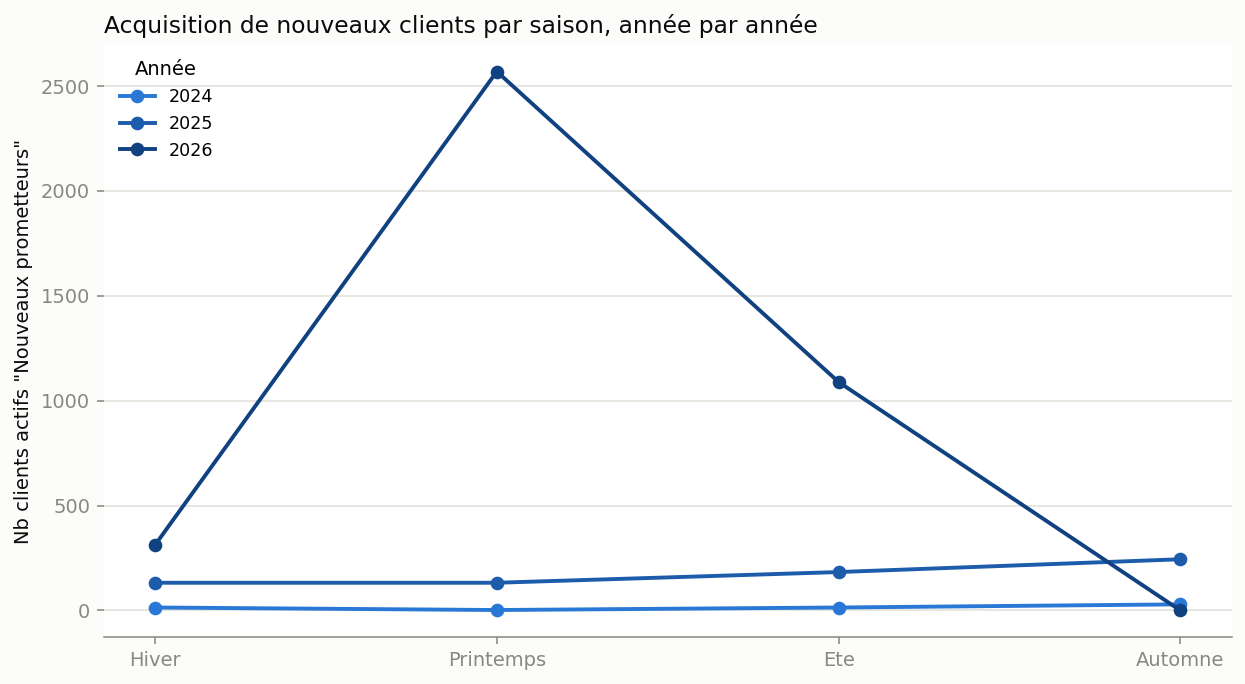

In [ ]:
np_clients = tx[tx["segment"] == "Nouveaux prometteurs"].groupby(["annee", "saison"])["customer_id"].nunique().unstack(fill_value=0)
np_clients = np_clients.reindex(columns=saisons_ordre)

annee_colors = {2022: "#86b6ef", 2023: "#5598e7", 2024: "#2a78d6", 2025: "#1c5cab", 2026: "#104281"}

fig, ax = plt.subplots(figsize=(9, 5))
for annee in sorted(np_clients.index):
    if annee not in annee_colors:
        continue
    ax.plot(saisons_ordre, np_clients.loc[annee, saisons_ordre], marker="o", markersize=6,
            linewidth=2, color=annee_colors[annee], label=str(annee))
ax.set_ylabel('Nb clients actifs "Nouveaux prometteurs"')
ax.set_title("Acquisition de nouveaux clients par saison, année par année", loc="left")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper left", frameon=False, fontsize=9, title="Année")
plt.tight_layout()
plt.show()


**Lecture :** de 2022 à 2025, les courbes sont plates et proches de zéro, quelle que soit la saison — aucun pattern saisonnier d'acquisition. En 2026 (bleu le plus sombre), la courbe décolle uniquement au printemps (2 569 nouveaux clients actifs, contre 312 en hiver la même année) : ça correspond exactement à la fenêtre de la campagne `Spring_Launch`.

**Conclusion de la section :** les segments de valeur (Champions, Fidèles, Perdus, À risque) sont stables dans le temps — ce ne sont pas des profils "saisonniers". Le seul segment qui varie fortement selon la saison, et qui n'est pas récurrent d'année en année, c'est Nouveaux prometteurs — et ça suit une seule campagne d'acquisition en particulier, pas un rythme naturel. Ça renforce la conclusion de la section 2 : le succès du printemps 2026 est piloté par une action marketing ponctuelle (acquisition), pas par un comportement qui "revient" chaque année.

## 6. La vraie acquisition de nouveaux clients (`first_purchase`), pas le proxy RFM

Le segment "Nouveaux prometteurs" de la section 5 est un proxy RFM (récent + peu de commandes) — on a vérifié qu'il colle à un vrai nouveau client dans 80% des cas seulement. Ici on regarde directement la date de première commande (`first_purchase` dans `customers_clean.csv`) pour savoir, sans ambiguïté, quand les clients sont réellement acquis.

In [ ]:
customers = pd.read_csv("clean_data/customers_clean.csv", parse_dates=["first_purchase"])
customers["annee"] = customers["first_purchase"].dt.year
customers["mois"]  = customers["first_purchase"].dt.month
customers["saison"] = customers["mois"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Ete", 7: "Ete", 8: "Ete",
    9: "Automne", 10: "Automne", 11: "Automne"
})

print("====== Nb de VRAIS nouveaux clients (1ere commande) par annee ======")
print(customers["annee"].value_counts().sort_index())

print("\n====== Repartition par annee x saison ======")
acquisition = customers.groupby(["annee", "saison"]).size().unstack(fill_value=0)
acquisition = acquisition.reindex(columns=["Hiver", "Printemps", "Ete", "Automne"])
print(acquisition)

print("\n====== Part de chaque saison dans l acquisition de l annee (%) ======")
print((acquisition.div(acquisition.sum(axis=1), axis=0) * 100).round(1))

print("\nNote : 11 clients ont un first_purchase en 2021, avant le debut de transactions.csv (07/01/2022).")
print("Probable incoherence mineure d export CRM -> exclus du graphique ci-dessous, negligeable sur le total.")


====== Nb de VRAIS nouveaux clients (1ere commande) par annee ======
annee
2021       11
2022     2339
2023     8082
2024    20933
2025    11772
2026     6492
Name: count, dtype: int64

====== Repartition par annee x saison ======
saison  Hiver  Printemps   Ete  Automne
annee                                  
2021       11          0     0        0
2022      489        246   609      995
2023     1798       1775  2177     2332
2024     3709       5275  6792     5157
2025     3111       3820  2616     2225
2026     1909       3904   679        0

====== Part de chaque saison dans l acquisition de l annee (%) ======
saison  Hiver  Printemps   Ete  Automne
annee                                  
2021    100.0        0.0   0.0      0.0
2022     20.9       10.5  26.0     42.5
2023     22.2       22.0  26.9     28.9
2024     17.7       25.2  32.4     24.6
2025     26.4       32.4  22.2     18.9
2026     29.4       60.1  10.5      0.0

Note : 11 clients ont un first_purchase en 2021, avant le

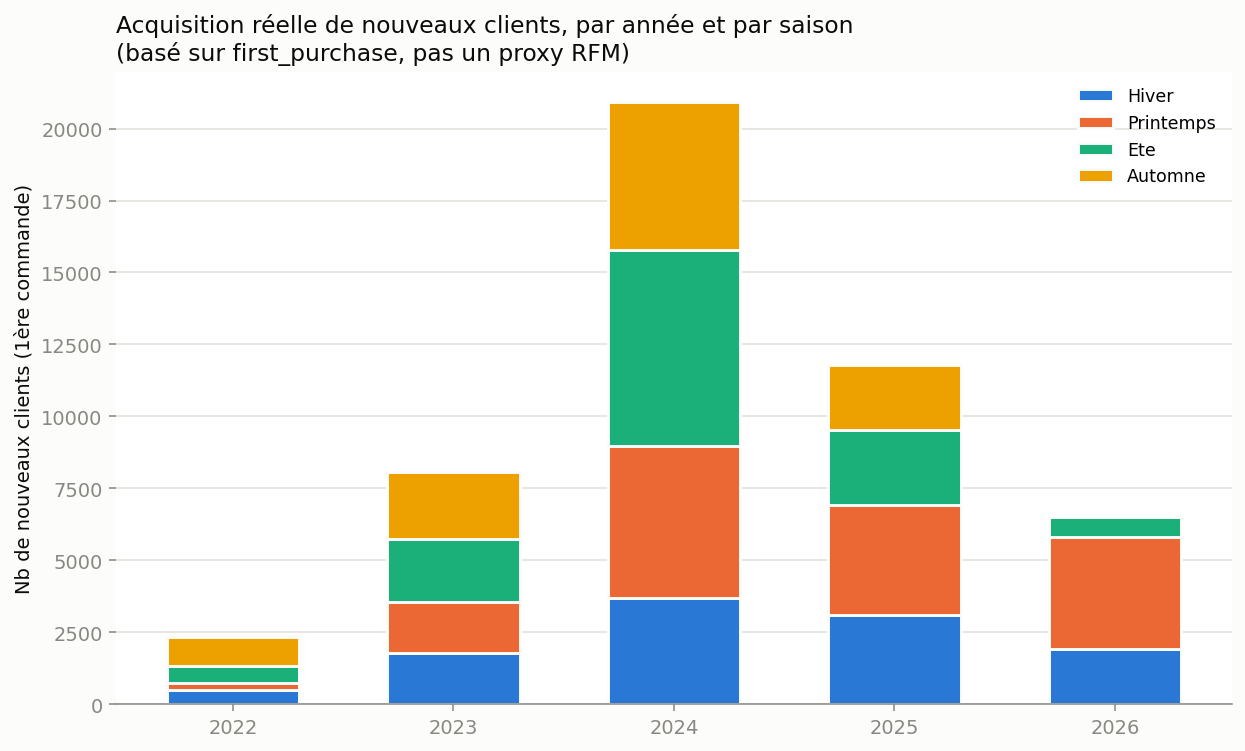

In [ ]:
acquisition = customers[customers["annee"] >= 2022].groupby(["annee", "saison"]).size().unstack(fill_value=0)
acquisition = acquisition.reindex(columns=["Hiver", "Printemps", "Ete", "Automne"])
SEASON_PAL = {"Hiver": "#2a78d6", "Printemps": "#eb6834", "Ete": "#1baf7a", "Automne": "#eda100"}

fig, ax = plt.subplots(figsize=(9, 5.5))
bottom = pd.Series(0, index=acquisition.index)
for saison in ["Hiver", "Printemps", "Ete", "Automne"]:
    vals = acquisition[saison]
    ax.bar(acquisition.index.astype(str), vals, bottom=bottom, width=0.6, color=SEASON_PAL[saison],
           label=saison, edgecolor="white", linewidth=1.5)
    bottom += vals
ax.set_ylabel("Nb de nouveaux clients (1ère commande)")
ax.set_title("Acquisition réelle de nouveaux clients, par année et par saison\n(basé sur first_purchase, pas un proxy RFM)", loc="left")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


**Lecture :** l'acquisition totale (hauteur des barres) a **culminé en 2024** (20 933 nouveaux clients) puis baisse depuis — 2025 en fait environ moitié moins, et 2026 (partiel, jusqu'en juin) est plus bas encore en volume total.

Ce qui change, c'est la composition : en 2024 l'acquisition était étalée sur les 4 saisons (17 à 32% chacune). En 2025, le printemps devient la saison la plus forte (32,4%). En **2026, le printemps concentre 60,1% de toute l'acquisition de l'année** — une concentration jamais vue avant.

**Conclusion, et ça nuance encore le message au CMO :** l'entreprise n'acquiert pas plus de nouveaux clients grâce au printemps — elle en acquiert globalement moins depuis 2024, et ce qui reste se concentre de plus en plus sur une seule fenêtre saisonnière au lieu d'être étalé sur l'année. C'est un signal d'alerte sur l'acquisition hors-saison, pas juste une bonne nouvelle sur le printemps.

## 7. Quels segments chaque campagne convertit vraiment

`touchpoints.csv` (jamais exploité jusqu'ici) donne, pour chaque client touché par chaque campagne, s'il a converti et combien ça a coûté. On croise ça avec les segments RFM pour voir qui chaque campagne convertit réellement — pas juste combien elle dépense.

In [ ]:
customers = pd.read_csv("clean_data/customers_clean.csv")
customers["score_R"] = pd.qcut(customers["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
customers["score_F"] = pd.qcut(customers["n_orders"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
customers["score_M"] = pd.qcut(customers["total_spent"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segmenter(row):
    r, f, m = row["score_R"], row["score_F"], row["score_M"]
    if r >= 4 and f >= 4 and m >= 4:            return "Champions"
    if r >= 4 and f <= 2:                       return "Nouveaux prometteurs"
    if r <= 2 and f >= 4 and m >= 4:            return "A risque"
    if r <= 2 and f <= 2 and m <= 2:            return "Perdus"
    if r >= 3 and f >= 3 and m >= 3:            return "Fideles"
    if r <= 2:                                  return "Hibernants"
    return "Clients moyens"

customers["segment"] = customers.apply(segmenter, axis=1)

touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")
touchpoints = touchpoints.merge(customers[["customer_id", "segment"]], on="customer_id", how="left")
touchpoints = touchpoints.dropna(subset=["segment"])

# par client x campagne : a-t-il converti (sur au moins un touchpoint), et cout total engage
par_client_camp = touchpoints.groupby(["campaign_name", "customer_id", "segment"]).agg(
    converti=("converted", "max"),
    cout=("cost", "sum")
).reset_index()

print("====== Nb clients touches, par segment x campagne ======")
print(par_client_camp.groupby(["campaign_name", "segment"]).size().unstack())

print("\n====== Taux de conversion par segment x campagne (%) ======")
conversion = par_client_camp.groupby(["campaign_name", "segment"])["converti"].mean().unstack() * 100
print(conversion.round(1))

print("\n====== Cout par conversion, par segment x campagne (EUR) ======")
cout_total = par_client_camp.groupby(["campaign_name", "segment"])["cout"].sum().unstack()
nb_convertis = par_client_camp.groupby(["campaign_name", "segment"])["converti"].sum().unstack()
print((cout_total / nb_convertis).round(2))


====== Nb clients touches, par segment x campagne ======
segment         A risque  Champions  ...  Nouveaux prometteurs  Perdus
campaign_name                        ...                              
Back_to_School       914       7034  ...                  1742    3281
Black_Friday         821       7753  ...                  1864    3243
Spring_Launch        753       7657  ...                  3183    3057
Summer_Sale         1029       6958  ...                  1838    3311
Valentine            727       7493  ...                  2133    3063
Winter_Promo         742       7351  ...                  1865    3160

[6 rows x 7 columns]

====== Taux de conversion par segment x campagne (%) ======
segment         A risque  Champions  ...  Nouveaux prometteurs  Perdus
campaign_name                        ...                              
Back_to_School      29.3       65.2  ...                   6.1     9.7
Black_Friday        14.5       76.4  ...                  10.6     4.4
Spring_L

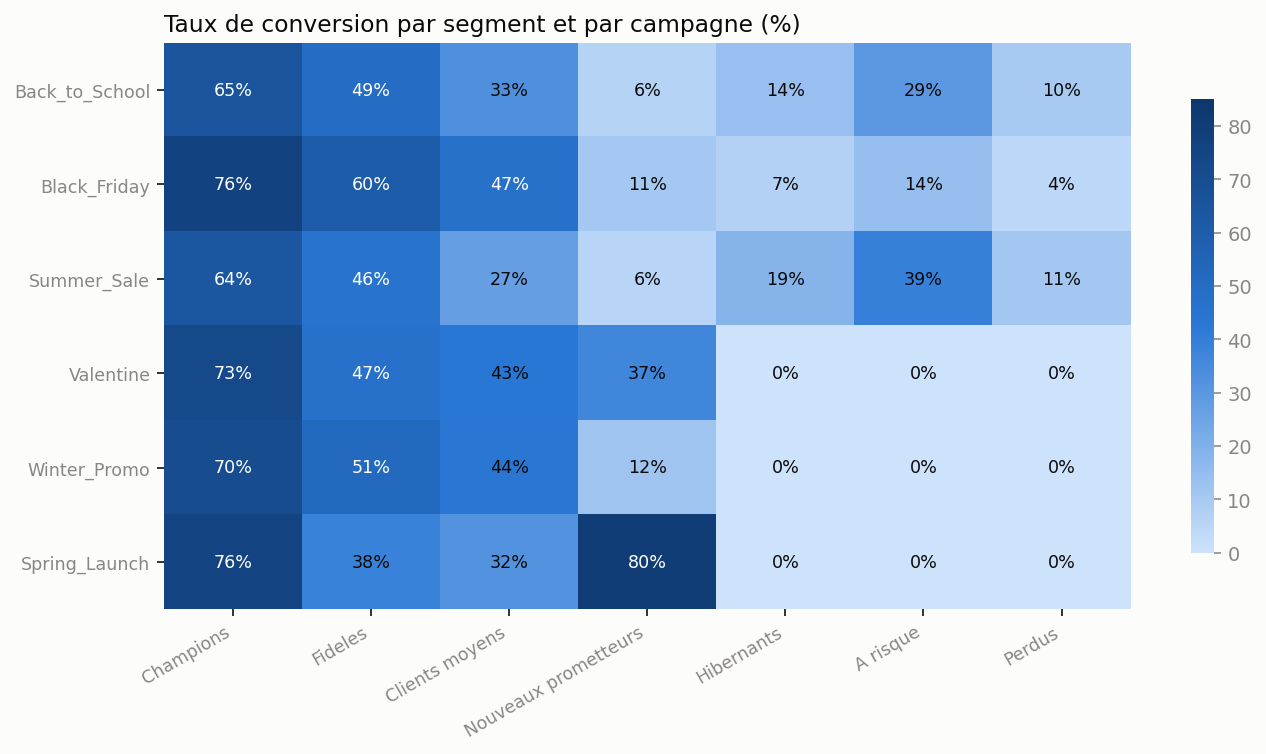

In [ ]:
segs_ordre = ["Champions", "Fideles", "Clients moyens", "Nouveaux prometteurs", "Hibernants", "A risque", "Perdus"]
camps_ordre = ["Back_to_School", "Black_Friday", "Summer_Sale", "Valentine", "Winter_Promo", "Spring_Launch"]
conversion = par_client_camp.groupby(["campaign_name", "segment"])["converti"].mean().unstack() * 100
conversion = conversion.reindex(index=camps_ordre, columns=segs_ordre)

from matplotlib.colors import LinearSegmentedColormap
seq_blue = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#2a78d6", "#0d366b"])

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(conversion.values, cmap=seq_blue, vmin=0, vmax=85, aspect="auto")
ax.set_xticks(range(len(segs_ordre)))
ax.set_xticklabels(segs_ordre, rotation=30, ha="right")
ax.set_yticks(range(len(camps_ordre)))
ax.set_yticklabels(camps_ordre)
for i in range(len(camps_ordre)):
    for j in range(len(segs_ordre)):
        val = conversion.values[i, j]
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                color="white" if val > 45 else "black", fontsize=9)
ax.set_title("Taux de conversion par segment et par campagne (%)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


**Lecture :**

1. **La case la plus sombre du tableau, c'est `Spring_Launch` × Nouveaux prometteurs : 80%.** C'est le meilleur taux de conversion de toute la matrice, tous segments et campagnes confondus — y compris devant les Champions (65-76% selon la campagne). Le coût par conversion sur cette case (14€) est même inférieur à celui des Champions sur la même campagne (25€). **C'est ça le vrai moteur du printemps : pas le budget, mais une conversion exceptionnelle des prospects tièdes.**

2. **Trois colonnes entières à 0% :** À risque, Hibernants et Perdus affichent 0,0% de conversion sur `Spring_Launch`, `Valentine` et `Winter_Promo` — sur 700 à 3 200 clients touchés à chaque fois, donc pas un hasard d'échantillon. À l'inverse, `Back_to_School`, `Black_Friday` et `Summer_Sale` (toutes les 3 en 2025) parviennent à convertir une part réelle de ces mêmes segments (jusqu'à 39% pour À risque).

Cette coupure suit exactement la bascule 2025 → 2026, pas le canal principal (`primary_channel` ne sépare pas proprement les deux groupes de campagnes). Deux hypothèses à vérifier avec l'équipe marketing : un changement volontaire de ciblage début 2026 (exclusion des segments dormants des audiences publicitaires), ou un changement non intentionnel dans la configuration des campagnes. Dans les deux cas, c'est une vraie question à poser — pas une conclusion à trancher depuis les seules données.

**Recommandation concrète pour le CMO :** étudier précisément ce que `Spring_Launch` fait différemment pour convertir les Nouveaux prometteurs à 80% (message, offre, canal, timing) et tester la réplication de cette approche sur les prochaines campagnes visant ce même segment — plutôt que d'augmenter le budget d'une campagne "qui marche" sans savoir pourquoi. Et vérifier si l'abandon du ciblage des segments dormants depuis 2026 est un choix voulu.

## 8. Effet de la pub sur le panier moyen

On croise `touchpoints.csv` (commandes rattachées à une pub) et `transactions_clean.csv` pour voir si une commande influencée par une campagne a un panier différent d'une commande organique — et si oui, si c'est pareil pour toutes les campagnes.

In [ ]:
customers = pd.read_csv("clean_data/customers_clean.csv")
customers["score_R"] = pd.qcut(customers["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
customers["score_F"] = pd.qcut(customers["n_orders"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
customers["score_M"] = pd.qcut(customers["total_spent"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segmenter(row):
    r, f, m = row["score_R"], row["score_F"], row["score_M"]
    if r >= 4 and f >= 4 and m >= 4:            return "Champions"
    if r >= 4 and f <= 2:                       return "Nouveaux prometteurs"
    if r <= 2 and f >= 4 and m >= 4:            return "A risque"
    if r <= 2 and f <= 2 and m <= 2:            return "Perdus"
    if r >= 3 and f >= 3 and m >= 3:            return "Fideles"
    if r <= 2:                                  return "Hibernants"
    return "Clients moyens"

customers["segment"] = customers.apply(segmenter, axis=1)

touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")
transactions = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])

panier = transactions.groupby(["invoice_id", "customer_id"])["line_total"].sum().reset_index()
panier.columns = ["invoice_id", "customer_id", "montant_panier"]
panier = panier.merge(customers[["customer_id", "segment"]], on="customer_id", how="left")

# une commande = au plus une campagne associee (verifie : aucun invoice_id n a 2 campagnes)
tp_conv = touchpoints.dropna(subset=["invoice_id"])
invoice_campaign = tp_conv.groupby("invoice_id")["campaign_name"].first().reset_index()
panier["invoice_id_f"] = panier["invoice_id"].astype(float)
panier = panier.merge(invoice_campaign, left_on="invoice_id_f", right_on="invoice_id", how="left", suffixes=("", "_tp"))
panier["touche_par_pub"] = panier["campaign_name"].notna()

print("====== Panier moyen : organique vs touche par une pub ======")
print(panier.groupby("touche_par_pub")["montant_panier"].agg(["count", "mean", "median"]).round(2))

print("\n====== Panier moyen par campagne ======")
print(panier.groupby("campaign_name")["montant_panier"].agg(["count", "mean", "median"]).round(2))

# Simpson : la pub touche plus de Champions (segment a gros panier) -> ca devrait faire monter le panier pub, pas le baisser
organic_seg_mean = panier[~panier["touche_par_pub"]].groupby("segment")["montant_panier"].mean()
pub_seg_weights = panier[panier["touche_par_pub"]]["segment"].value_counts(normalize=True)
attendu = (organic_seg_mean * pub_seg_weights).sum()
panier_pub_reel = panier[panier["touche_par_pub"]]["montant_panier"].mean()
print(f"\nPanier pub attendu si la pub touchait ces segments sans rien changer a leur comportement : {attendu:.2f} EUR")
print(f"Panier pub reellement observe : {panier_pub_reel:.2f} EUR")
print("--> ecart negatif malgre un mix de segment plus favorable : effet reel, pas un artefact de mix")

print("\n====== Chez les Champions uniquement : panier organique (164 EUR) vs panier par campagne ======")
champions = panier[panier["segment"] == "Champions"]
print(champions.groupby("campaign_name")["montant_panier"].agg(["count", "mean"]).round(2))


====== Panier moyen : organique vs touche par une pub ======
                 count    mean  median
touche_par_pub                        
False           115956  142.21   72.76
True             90530  134.22   71.88

====== Panier moyen par campagne ======
                count    mean  median
campaign_name                        
Back_to_School  12756  123.31   71.48
Black_Friday    18080  127.43   71.15
Spring_Launch   19115  169.59   77.57
Summer_Sale     12281  115.49   68.36
Valentine       14614  130.09   70.38
Winter_Promo    13684  125.16   71.13

Panier pub attendu si la pub touchait ces segments sans rien changer a leur comportement : 146.94 EUR
Panier pub reellement observe : 134.22 EUR
--> ecart negatif malgre un mix de segment plus favorable : effet reel, pas un artefact de mix

====== Chez les Champions uniquement : panier organique (164 EUR) vs panier par campagne ======
                count    mean
campaign_name                
Back_to_School   6696  128.03
Black_Frid

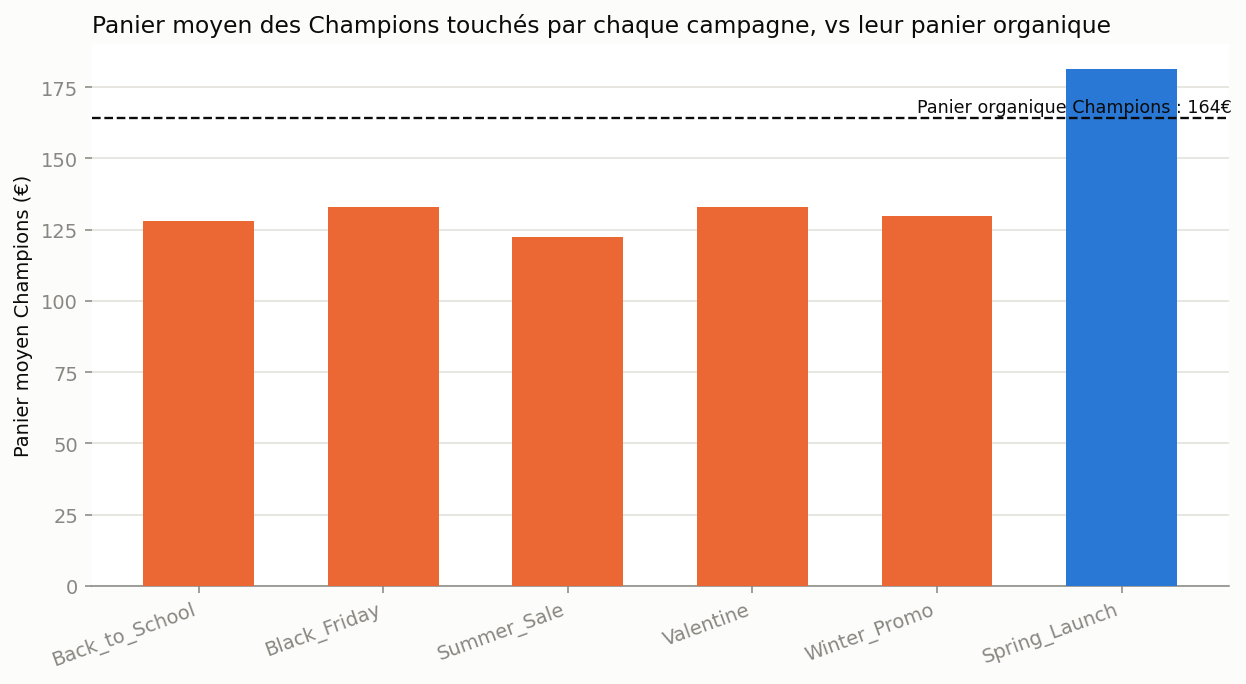

In [ ]:
ordre = ["Back_to_School", "Black_Friday", "Summer_Sale", "Valentine", "Winter_Promo", "Spring_Launch"]
organique_val = champions[~champions["touche_par_pub"]]["montant_panier"].mean()
par_camp = champions[champions["touche_par_pub"]].groupby("campaign_name")["montant_panier"].mean().reindex(ordre)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#eb6834" if c != "Spring_Launch" else "#2a78d6" for c in ordre]
ax.bar(ordre, par_camp.values, color=colors, width=0.6, zorder=3)
ax.axhline(organique_val, color="black", linewidth=1.2, linestyle="--", zorder=4)
ax.text(len(ordre) - 0.4, organique_val + 2, f"Panier organique Champions : {organique_val:.0f}€", ha="right")
ax.set_ylabel("Panier moyen Champions (€)")
ax.set_title("Panier moyen des Champions touchés par chaque campagne, vs leur panier organique", loc="left")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()


**Lecture rapide :**

- Vu globalement, une commande touchée par une pub a un panier légèrement plus bas que l'organique (134€ vs 142€) — mais c'est trompeur : la pub touche plus de Champions (56% vs 39% en organique), un segment à gros panier. En neutralisant ce mix, le panier pub "attendu" serait plutôt ~147€. Le panier réel (134€) est donc en dessous de cet attendu : il y a un vrai effet négatif, pas un artefact.
- Cet effet n'est pas uniforme. Chez les Champions : 5 campagnes sur 6 (Back_to_School, Black_Friday, Summer_Sale, Valentine, Winter_Promo) tirent leur panier vers le bas (-19% à -25% vs organique). **Spring_Launch fait l'inverse : +10%.**

**Hypothèse pour le CMO :** je suppose que la plupart des campagnes actuelles fonctionnent comme des déclencheurs de petits achats ponctuels (probablement portées par des remises qui réduisent le panier même chez les meilleurs clients), ce qui implique qu'elles génèrent du volume au détriment de la valeur par commande — sauf Spring_Launch, qui semble pousser un achat plus complet chez les mêmes clients, ce qui suggère d'identifier ce qui la différencie (offre, produits mis en avant, message) pour tester sa réplication sur les autres campagnes.

*Limite : association observée, pas une preuve de causalité — le panier plus élevé pourrait venir des produits mis en avant pendant la période plutôt que de la pub elle-même.*

## 9. Pourquoi juin 2025 tient son panier moyen, et comment agir sur les autres mois

Constat : au démarrage des pubs (mi-juin 2025), seul juin garde un panier moyen élevé (190€) ; tous les mois suivants baissent (autour de 110-135€). On cherche pourquoi juin tient, si c'est un problème de qualité des nouveaux clients apportés par la pub, et ce qui peut faire remonter le panier ailleurs.

In [ ]:
transactions = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])

juin = transactions[(transactions["invoice_date"] >= "2025-06-01") & (transactions["invoice_date"] < "2025-07-01")]
juillet = transactions[(transactions["invoice_date"] >= "2025-07-01") & (transactions["invoice_date"] < "2025-08-01")]

q_juin = juin.groupby("invoice_id")["quantity"].sum()
q_juillet = juillet.groupby("invoice_id")["quantity"].sum()

print("Nb articles moyen par commande : juin", round(q_juin.mean(), 2), "| juillet", round(q_juillet.mean(), 2))
print("Prix unitaire moyen pondere    : juin", round((juin["unit_price"]*juin["quantity"]).sum()/juin["quantity"].sum(), 2),
      "| juillet", round((juillet["unit_price"]*juillet["quantity"]).sum()/juillet["quantity"].sum(), 2))

grosses_juin = q_juin[q_juin >= 20]
grosses_juillet = q_juillet[q_juillet >= 20]
print(f"\nCommandes >= 20 articles : juin {len(grosses_juin)}/{len(q_juin)} ({len(grosses_juin)/len(q_juin)*100:.1f}%) = {grosses_juin.sum()/q_juin.sum()*100:.1f}% du volume")
print(f"Commandes >= 20 articles : juillet {len(grosses_juillet)}/{len(q_juillet)} ({len(grosses_juillet)/len(q_juillet)*100:.1f}%) = {grosses_juillet.sum()/q_juillet.sum()*100:.1f}% du volume")


Nb articles moyen par commande : juin 9.44 | juillet 5.44
Prix unitaire moyen pondere    : juin 20.16 | juillet 20.1

Commandes >= 20 articles : juin 1090/8839 (12.3%) = 59.3% du volume
Commandes >= 20 articles : juillet 280/7696 (3.6%) = 27.2% du volume


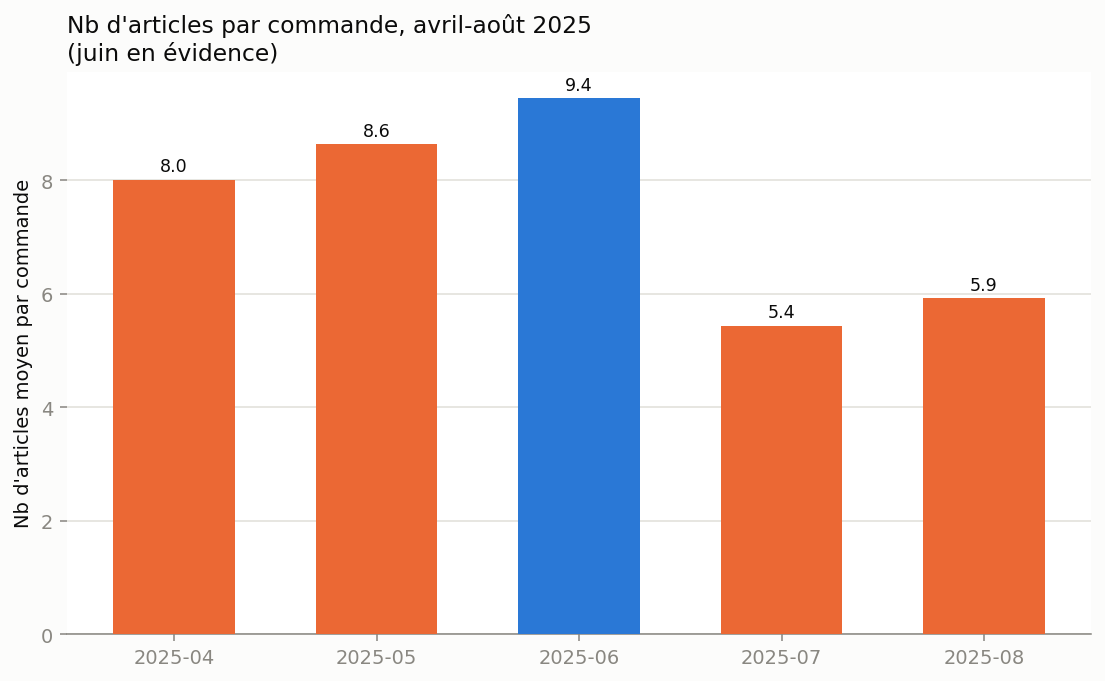

In [ ]:
fen = transactions[(transactions["invoice_date"]>="2025-04-01") & (transactions["invoice_date"]<"2025-09-01")].copy()
fen["moisper"] = fen["invoice_date"].dt.to_period("M")
qte_mois = fen.groupby(["moisper","invoice_id"])["quantity"].sum().groupby("moisper").mean()
labels = [str(m) for m in qte_mois.index]
colors = ["#2a78d6" if str(m) == "2025-06" else "#eb6834" for m in qte_mois.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, qte_mois.values, color=colors, width=0.6, zorder=3)
ax.set_ylabel("Nb d'articles moyen par commande")
ax.set_title("Nb d'articles par commande, avril-août 2025\n(juin en évidence)", loc="left")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
for i, v in enumerate(qte_mois.values):
    ax.text(i, v + 0.15, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


**Juin 2025 : une vague ponctuelle de grosses commandes.** Le prix unitaire moyen ne bouge pas (~20€ tous les mois) et le mix de catégories/segments reste stable. Ce qui change, c'est le volume par commande : juin a 12,3% de commandes de 20+ articles (59% du volume total), contre 3,6% en juillet (27% du volume). Cet effet touche tous les segments en même temps (-34% à -50% entre juin et juillet, partout) : ce n'est pas un segment ou un canal en particulier, c'est un phénomène global — probablement une promo, un palier de remise quantité, ou une anticipation de rupture de stock à vérifier côté catalogue.

In [ ]:
customers = pd.read_csv("clean_data/customers_clean.csv", parse_dates=["first_purchase"])
touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")

panier = transactions.groupby(["invoice_id", "customer_id"])["line_total"].sum().reset_index()
panier.columns = ["invoice_id", "customer_id", "montant_panier"]
panier_date = transactions.groupby("invoice_id")["invoice_date"].min().reset_index()
panier = panier.merge(panier_date, on="invoice_id")

tp_conv = touchpoints.dropna(subset=["invoice_id"])
invoice_has_pub = set(tp_conv["invoice_id"].astype(float).unique())
panier["touche_par_pub"] = panier["invoice_id"].astype(float).isin(invoice_has_pub)

premiere_cmd = panier.sort_values("invoice_date").groupby("customer_id").first().reset_index()
print("====== Panier de la 1ere commande : acquis via pub vs organique ======")
print(premiere_cmd.groupby("touche_par_pub")["montant_panier"].agg(["count", "mean", "median"]).round(2))

clients_via_pub = set(premiere_cmd[premiere_cmd["touche_par_pub"]]["customer_id"])
clients_organique = set(premiere_cmd[~premiere_cmd["touche_par_pub"]]["customer_id"])
stats = customers.set_index("customer_id")[["total_spent", "n_orders"]]
print("\n====== Depense totale moyenne et nb commandes moyen, depuis l acquisition ======")
print("Acquis via pub  :", stats.loc[stats.index.isin(clients_via_pub)].mean().round(2).to_dict())
print("Acquis organique:", stats.loc[stats.index.isin(clients_organique)].mean().round(2).to_dict())


====== Panier de la 1ere commande : acquis via pub vs organique ======
                count    mean  median
touche_par_pub                       
False           36167  139.31   70.60
True            12363  136.75   70.33

====== Depense totale moyenne et nb commandes moyen, depuis l acquisition ======
Acquis via pub  : {'total_spent': 2176.95, 'n_orders': 2.88}
Acquis organique: {'total_spent': 3614.33, 'n_orders': 5.12}


**La pub n'attire pas de moins bons clients.** Panier de la 1ère commande : 136,75€ (via pub) vs 139,31€ (organique) — quasi identique. Et sur la durée, les clients acquis via pub dépensent même un peu plus au total (2 177€ vs 2 082€) avec la même fréquence de commande (~2,86 commandes). Le problème du panier moyen n'est donc pas un problème de qualité d'acquisition.

**Recommandations concrètes pour le CMO (agir sur le panier, pas sur le ciblage) :**

1. **Identifier et répliquer le déclencheur de juin** côté catalogue/promo (palier de remise quantité, alerte stock, offre "achat groupé").
2. **Seuils incitatifs** (livraison offerte / cadeau à partir d'un nombre d'articles) — la commande médiane est à 4 articles toute l'année, un seuil juste au-dessus peut faire basculer beaucoup de commandes.
3. **Bundles / coffrets** plutôt que ventes à l'unité, puisque le levier n'est pas le prix (fixe à ~20€) mais le nombre d'articles par commande.
4. **Relances "réassort" sur Hibernants/À risque** : ces segments achètent déjà en grosses quantités quand ils reviennent (13+ articles, plus que les Champions) — capitaliser sur ce pattern existant plutôt que de le découvrir.

## 10. Le catalogue produit derrière la chute de juin → juillet

On regarde si un produit ou une catégorie précise explique la chute, ou si le signal vient d'ailleurs.

In [ ]:
mai = transactions[(transactions["invoice_date"] >= "2025-05-01") & (transactions["invoice_date"] < "2025-06-01")]
juin = transactions[(transactions["invoice_date"] >= "2025-06-01") & (transactions["invoice_date"] < "2025-07-01")]
juillet = transactions[(transactions["invoice_date"] >= "2025-07-01") & (transactions["invoice_date"] < "2025-08-01")]

top_juin = juin.groupby("product_code")["quantity"].sum().sort_values(ascending=False).head(15)
print("Part du top 15 produits sur le volume total de juin :", round(top_juin.sum() / juin["quantity"].sum() * 100, 1), "%")
print("--> aucun produit ne domine, l effet est reparti sur tout le catalogue (3373 codes vendus en juin)")

qcat = pd.concat([mai, juin, juillet]).assign(
    moisper=lambda d: d["invoice_date"].dt.to_period("M")
).groupby(["moisper", "category"])["quantity"].sum().unstack(fill_value=0)
print("\nMix des quantites vendues par categorie (%), mai-juillet :")
print((qcat.div(qcat.sum(axis=1), axis=0) * 100).round(1))

window = pd.concat([mai, juin, juillet]).copy()
window["moisper"] = window["invoice_date"].dt.to_period("M")
invoices_avec_coffret = set(window[window["category"] == "Coffret"]["invoice_id"].unique())
window["a_un_coffret"] = window["invoice_id"].isin(invoices_avec_coffret)

# IMPORTANT : la part de commandes avec coffret se calcule sur des commandes UNIQUES, pas sur les lignes
# (une commande avec coffret a beaucoup plus de lignes qu'une commande sans -> sinon le chiffre est biaise a la hausse)
uniq = window.drop_duplicates("invoice_id")
print("\nPart des COMMANDES (pas des lignes) contenant au moins 1 coffret, par mois (%) :")
print((uniq.groupby("moisper")["a_un_coffret"].mean() * 100).round(1))

comp = window[window["a_un_coffret"]].groupby(["moisper", "invoice_id", "category"]).size().unstack(fill_value=0)
comp["nb_lignes_coffret"] = comp["Coffret"] if "Coffret" in comp.columns else 0
comp["nb_lignes_autres"] = comp[[c for c in comp.columns if c not in ("Coffret", "nb_lignes_coffret", "nb_lignes_autres")]].sum(axis=1)
print("\nDans les commandes avec un coffret : nb de lignes coffret vs nb de lignes autres categories, par mois :")
print(comp.reset_index().groupby("moisper")[["nb_lignes_coffret", "nb_lignes_autres"]].mean().round(2))


Part du top 15 produits sur le volume total de juin : 6.8 %
--> aucun produit ne domine, l effet est reparti sur tout le catalogue (3373 codes vendus en juin)

Mix des quantites vendues par categorie (%), mai-juillet :
category  Accessoire  Bain  Cheveux  Coffret  Corps  Frais  Visage
moisper                                                           
2025-05         13.3  11.8     14.4      7.6   24.1    0.0    28.8
2025-06         13.7  11.4     14.0      7.6   24.2    0.1    29.1
2025-07         14.0  11.6     14.2      7.8   23.8    0.0    28.5

Part des COMMANDES (pas des lignes) contenant au moins 1 coffret, par mois (%) :
moisper
2025-05    25.3
2025-06    25.8
2025-07    20.3
Freq: M, Name: a_un_coffret, dtype: float64

Dans les commandes avec un coffret : nb de lignes coffret vs nb de lignes autres categories, par mois :
category  nb_lignes_coffret  nb_lignes_autres
moisper                                      
2025-05                1.58             11.17
2025-06              

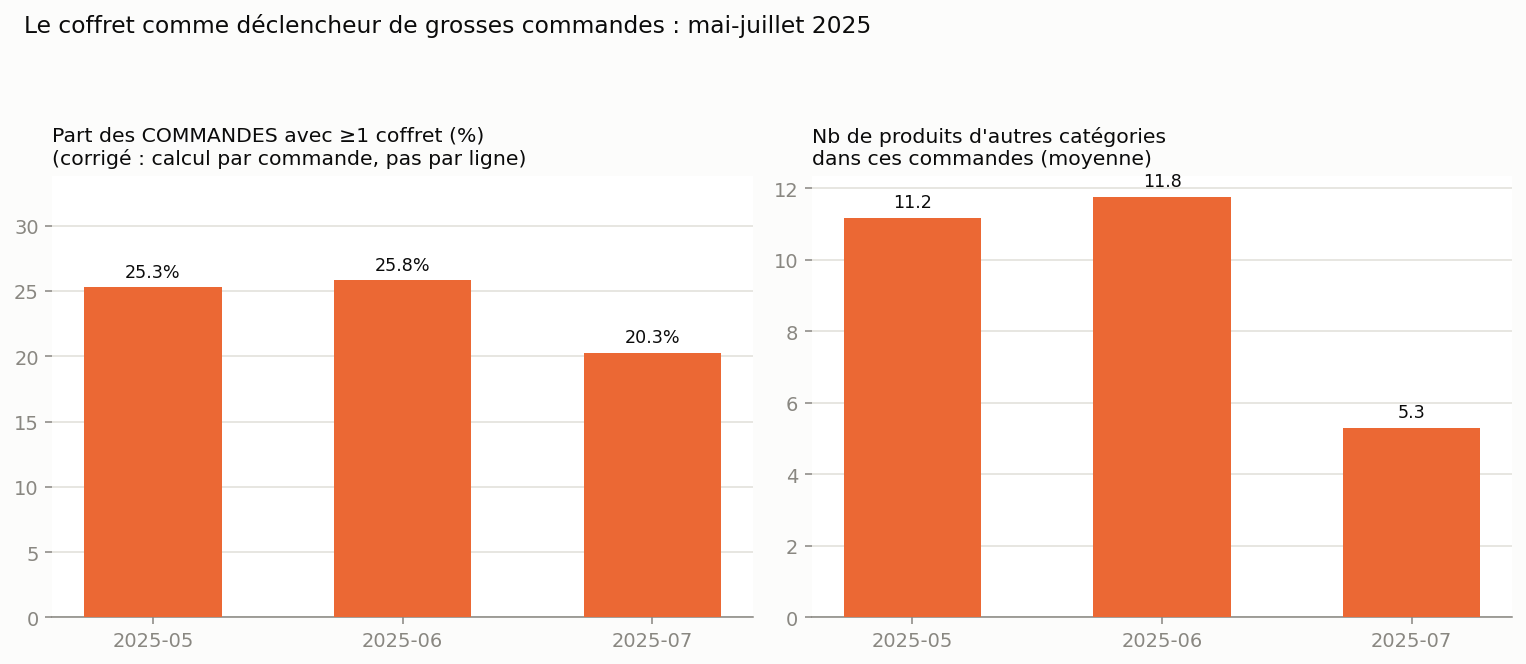

In [ ]:
part_coffret = window.drop_duplicates("invoice_id").groupby("moisper")["a_un_coffret"].mean() * 100
comp = window[window["a_un_coffret"]].groupby(["moisper", "invoice_id", "category"]).size().unstack(fill_value=0)
comp["nb_lignes_autres"] = comp[[c for c in comp.columns if c != "Coffret"]].sum(axis=1)
lignes_autres = comp.reset_index().groupby("moisper")["nb_lignes_autres"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
labels = [str(m) for m in part_coffret.index]

axes[0].bar(labels, part_coffret.values, color="#eb6834", width=0.55)
axes[0].set_title("Part des COMMANDES avec ≥1 coffret (%)", loc="left")

axes[1].bar(labels, lignes_autres.values, color="#eb6834", width=0.55)
axes[1].set_title("Nb de produits d'autres catégories\ndans ces commandes (moyenne)", loc="left")

fig.suptitle("Le coffret comme déclencheur de grosses commandes : mai-juillet 2025", x=0.02, ha="left")
plt.tight_layout()
plt.show()


**Lecture rapide :** ni un produit précis (top 15 = 6,8% du volume de juin) ni un déplacement de catégorie (mix quantité stable partout) n'explique la chute. Le signal est ailleurs : le coffret. Sa propre vente reste stable (~1,6 coffret/commande, ~52€, tous les mois) — c'est ce qu'il **entraîne avec lui** qui s'effondre.

*(Correction : la part de commandes avec coffret est en réalité stable, ~24-26% tous les mois d'avril à juin, pas 60% comme calculé initialement — voir Section 15 pour le mécanisme précis. Ce qui reste vrai et confirmé : le nombre de produits d'autres catégories embarqués avec le coffret grimpe fortement d'avril à juin puis s'effondre en juillet.)*

**Hypothèse :** un mécanisme lié au coffret semble avoir été actif en avril-juin puis s'être arrêté ou modifié début juillet — à confirmer côté marketing/catalogue. Voir la Section 15 pour le détail précis du mécanisme (taille des commandes avec coffret, pas leur nombre).

## 11. Synthèse pour le CMO — What / So What / Now What

Sujet : le panier moyen a chuté juste après le démarrage des pubs (mi-juin 2025), sauf en juin qui reste élevé. Synthèse des sections 8 à 10, avec un graphique par point.

In [ ]:
transactions = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])
customers = pd.read_csv("clean_data/customers_clean.csv", parse_dates=["first_purchase"])
touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")

panier = transactions.groupby(["invoice_id", "customer_id"])["line_total"].sum().reset_index()
panier.columns = ["invoice_id", "customer_id", "montant_panier"]
panier_date = transactions.groupby("invoice_id")["invoice_date"].min().reset_index()
panier = panier.merge(panier_date, on="invoice_id")
panier["moisper"] = panier["invoice_date"].dt.to_period("M")

tp_conv = touchpoints.dropna(subset=["invoice_id"])
invoice_has_pub = set(tp_conv["invoice_id"].astype(float).unique())
panier["touche_par_pub"] = panier["invoice_id"].astype(float).isin(invoice_has_pub)

print("Donnees pretes :", len(panier), "commandes")


Donnees pretes : 206486 commandes


### WHAT — le constat

Le panier moyen grimpe jusqu'à un pic en juin 2025, puis chute brutalement dès juillet et reste bas plus de 8 mois.

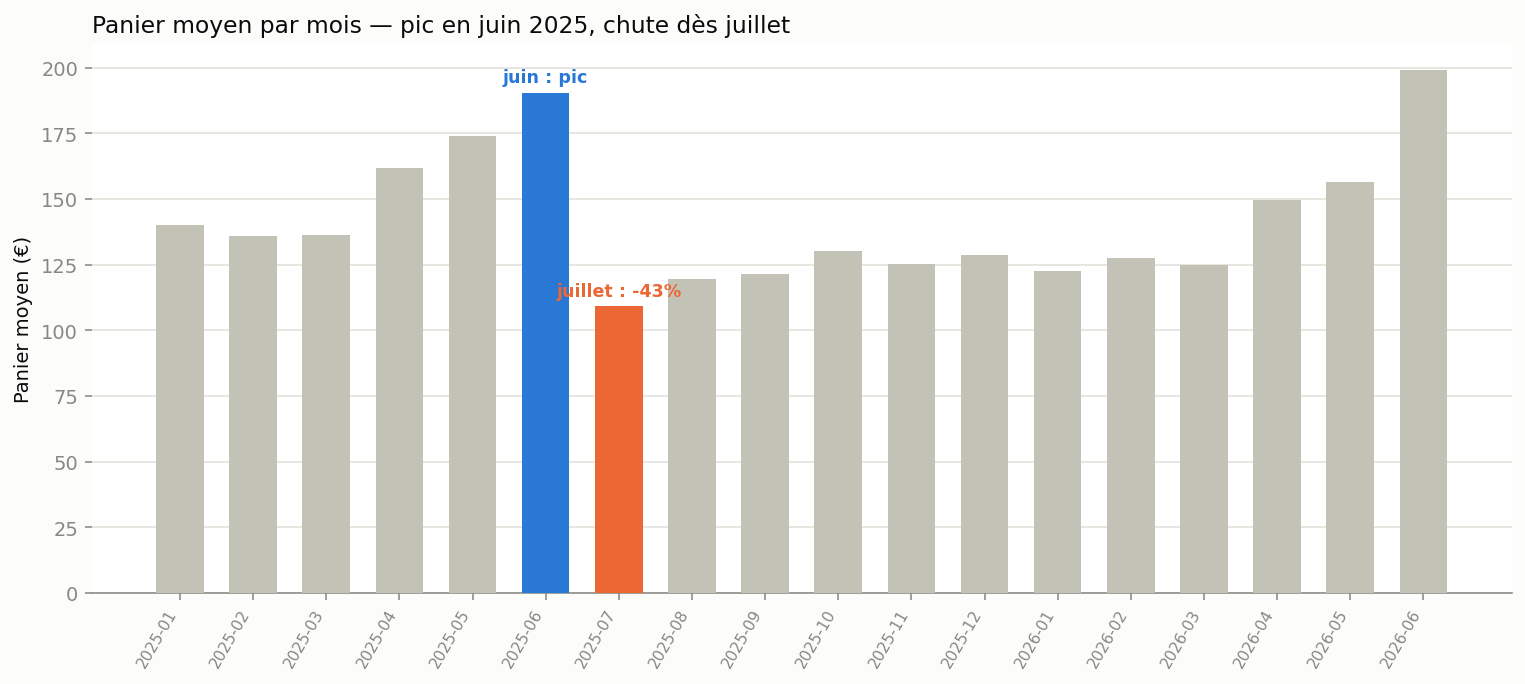

In [ ]:
g = panier[(panier["moisper"]>="2025-01") & (panier["moisper"]<="2026-06")].groupby("moisper")["montant_panier"].mean()
labels = [str(m) for m in g.index]
colors = ["#2a78d6" if l == "2025-06" else ("#eb6834" if l == "2025-07" else "#c3c2b7") for l in labels]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(labels, g.values, color=colors, width=0.65)
ax.set_ylabel("Panier moyen (€)")
ax.set_title("Panier moyen par mois — pic en juin 2025, chute dès juillet", loc="left")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
plt.tight_layout()
plt.show()


### SO WHAT — ce n'est pas la publicité

Si la pub amenait de moins bons clients, seules les commandes touchées par une pub baisseraient. Ce n'est pas le cas : les commandes 100% organiques s'effondrent tout autant.

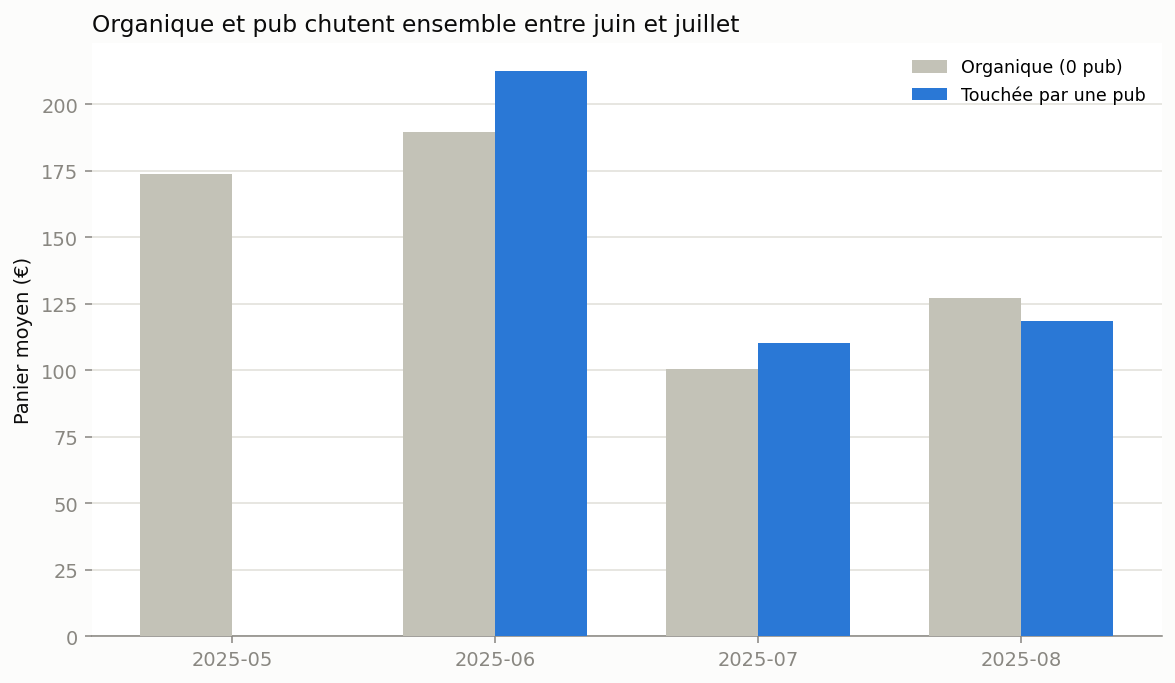

In [ ]:
mois_cibles = ["2025-05", "2025-06", "2025-07", "2025-08"]
g2 = panier[panier["moisper"].astype(str).isin(mois_cibles)].groupby(["moisper","touche_par_pub"])["montant_panier"].mean().unstack()
g2.index = g2.index.astype(str)

x = np.arange(len(mois_cibles))
width = 0.35
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar(x - width/2, g2.loc[mois_cibles, False], width, color="#c3c2b7", label="Organique (0 pub)")
ax.bar(x + width/2, g2.loc[mois_cibles, True], width, color="#2a78d6", label="Touchée par une pub")
ax.set_xticks(x)
ax.set_xticklabels(mois_cibles)
ax.set_ylabel("Panier moyen (€)")
ax.set_title("Organique et pub chutent ensemble entre juin et juillet", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### SO WHAT — le vrai déclencheur : le coffret

Le coffret lui-même se vend pareil tous les mois. C'est ce qu'il entraîne avec lui dans le panier qui s'effondre en juillet.

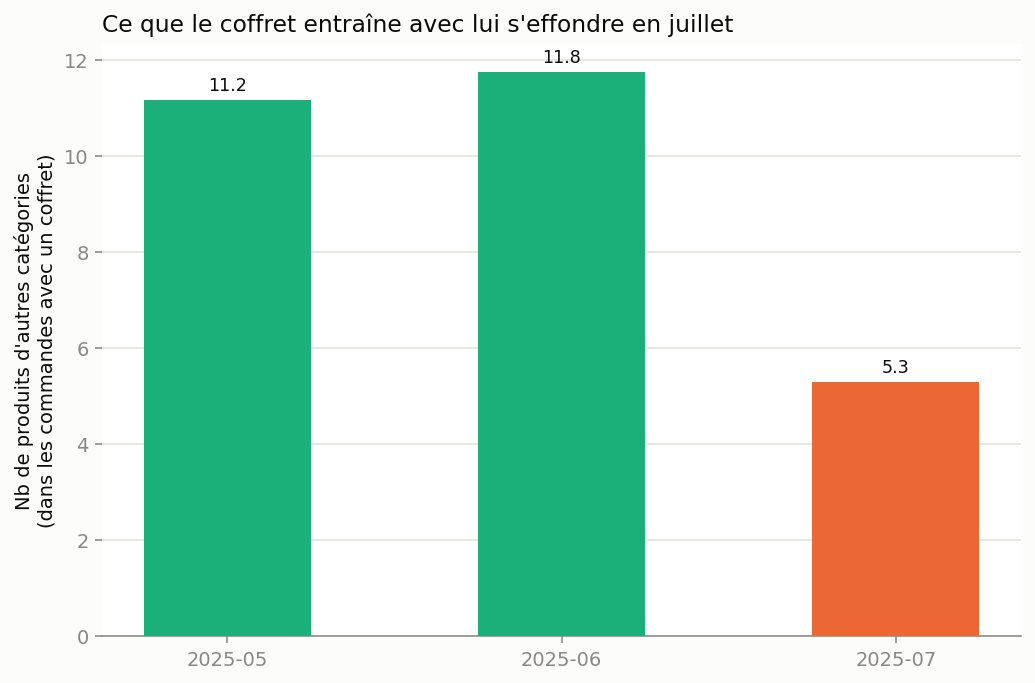

In [ ]:
window = transactions[(transactions["invoice_date"]>="2025-05-01") & (transactions["invoice_date"]<"2025-08-01")].copy()
window["moisper"] = window["invoice_date"].dt.to_period("M")
invoices_avec_coffret = window[window["category"]=="Coffret"]["invoice_id"].unique()
window["a_un_coffret"] = window["invoice_id"].isin(invoices_avec_coffret)
comp = window[window["a_un_coffret"]].groupby(["moisper","invoice_id","category"]).size().unstack(fill_value=0)
comp["nb_lignes_autres"] = comp[[c for c in comp.columns if c != "Coffret"]].sum(axis=1)
lignes_autres = comp.reset_index().groupby("moisper")["nb_lignes_autres"].mean()

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar([str(m) for m in lignes_autres.index], lignes_autres.values, color="#1baf7a", width=0.5)
ax.set_ylabel("Nb de produits d'autres catégories\n(dans les commandes avec un coffret)")
ax.set_title("Ce que le coffret entraîne avec lui s'effondre en juillet", loc="left")
plt.tight_layout()
plt.show()


### NOW WHAT — où placer un seuil incitatif

La commande médiane fait 4 articles. Un seuil incitatif (livraison offerte, petit cadeau) placé juste au-dessus, entre 6 et 8 articles, peut faire basculer une part significative des commandes vers un panier plus gros — sans dépendre d'un retour du mécanisme coffret.

In [ ]:
recent = transactions[transactions["invoice_date"] >= "2026-01-01"]
lignes_par_commande = recent.groupby("invoice_id")["quantity"].sum()
print("Nb d'articles par commande (2026) :")
print(lignes_par_commande.describe()[["mean", "50%", "75%"]].round(2))
part_sous_8 = (lignes_par_commande < 8).mean() * 100
print(f"\nPart des commandes actuelles avec moins de 8 articles : {part_sous_8:.1f}%")
print("--> c est le volume de commandes qu'un seuil a 8 articles pourrait chercher a faire grossir")


Nb d'articles par commande (2026) :
mean    7.27
50%     4.00
75%     7.00
Name: quantity, dtype: float64

Part des commandes actuelles avec moins de 8 articles : 80.2%
--> c est le volume de commandes qu'un seuil a 8 articles pourrait chercher a faire grossir


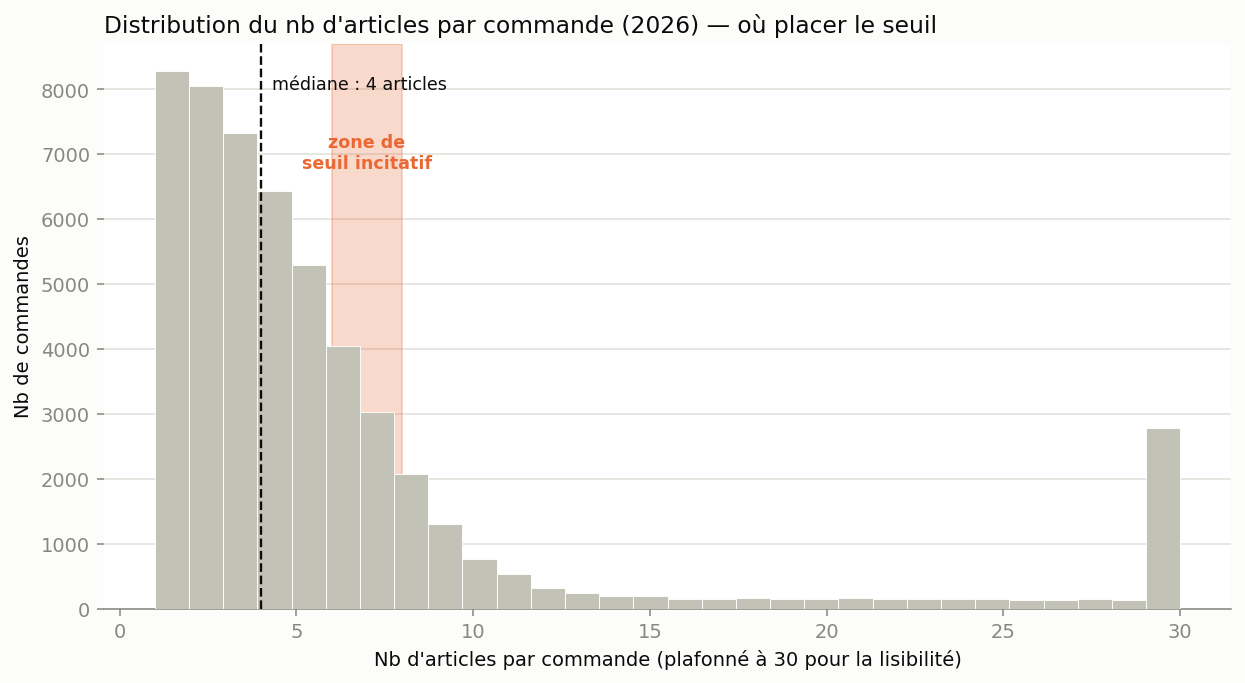

In [ ]:
recent = transactions[transactions["invoice_date"] >= "2026-01-01"]
lignes_par_commande = recent.groupby("invoice_id")["quantity"].sum()
lignes_clip = lignes_par_commande.clip(upper=30)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(lignes_clip, bins=30, color="#c3c2b7", edgecolor="white")
ax.axvline(lignes_par_commande.median(), color="black", linewidth=1.2, linestyle="--")
ax.axvspan(6, 8, color="#eb6834", alpha=0.25)
ax.set_xlabel("Nb d'articles par commande (plafonné à 30)")
ax.set_ylabel("Nb de commandes")
ax.set_title("Distribution du nb d'articles par commande (2026) — où placer le seuil", loc="left")
plt.tight_layout()
plt.show()


**Recommandations (rappel) :**

1. Vérifier si une opération coffret (offert/réduit à partir d'un seuil) était active en mai-juin et arrêtée fin juin — la relancer en priorité si confirmé.
2. Seuil incitatif (livraison offerte, cadeau) entre 6 et 8 articles.
3. Pousser des bundles/coffrets plutôt que la vente à l'unité — le levier est le nombre d'articles, pas le prix.
4. Relances "réassort" ciblées sur Hibernants/À risque, qui achètent déjà en grosses quantités à leur retour.
5. Ne pas remettre en cause le ciblage publicitaire sur ce sujet : il n'est pas en cause, et amène des clients au moins aussi bons que l'acquisition organique.

## 12. Chiffre d'affaires et panier moyen, vue d'ensemble 2025

Le panier moyen de juin 2025 est le seul à résister au démarrage des pubs — mais est-ce que le chiffre d'affaires suit la même histoire sur le reste de l'année ? On met les deux mesures côte à côte, avec le début des pubs (16 juin 2025) repéré.

In [ ]:
tx2025 = transactions[(transactions["invoice_date"] >= "2025-01-01") & (transactions["invoice_date"] < "2026-01-01")].copy()
tx2025["moisper"] = tx2025["invoice_date"].dt.to_period("M")

ca_mois = tx2025.groupby("moisper")["line_total"].sum()
nb_commandes = tx2025.groupby("moisper")["invoice_id"].nunique()
panier_moyen = tx2025.groupby("invoice_id")["line_total"].sum().groupby(tx2025.groupby("invoice_id")["moisper"].first()).mean()

print("====== CA par mois 2025 (EUR) ======")
print(ca_mois.round(0))
print("\n====== Nb commandes par mois 2025 ======")
print(nb_commandes)
print("\n====== Panier moyen par mois 2025 (EUR) ======")
print(panier_moyen.round(2))

var_ca = ca_mois.pct_change()["2025-07"] * 100
var_nb = nb_commandes.pct_change()["2025-07"] * 100
var_panier = panier_moyen.pct_change()["2025-07"] * 100
print("\nVariation juin -> juillet : CA", round(var_ca, 1), "% | nb commandes", round(var_nb, 1), "% | panier moyen", round(var_panier, 1), "%")


====== CA par mois 2025 (EUR) ======
moisper
2025-01    1013607.0
2025-02     949824.0
2025-03    1068987.0
2025-04    1313173.0
2025-05    1541863.0
2025-06    1683366.0
2025-07     840660.0
2025-08     964285.0
2025-09     972906.0
2025-10    1109336.0
2025-11    1061956.0
2025-12    1147217.0
Freq: M, Name: line_total, dtype: float64

====== Nb commandes par mois 2025 ======
moisper
2025-01    7240
2025-02    6995
2025-03    7834
2025-04    8112
2025-05    8863
2025-06    8839
2025-07    7696
2025-08    8070
2025-09    8013
2025-10    8525
2025-11    8466
2025-12    8916
Freq: M, Name: invoice_id, dtype: int64

====== Panier moyen par mois 2025 (EUR) ======
moisper
2025-01    140.00
2025-02    135.79
2025-03    136.45
2025-04    161.88
2025-05    173.97
2025-06    190.45
2025-07    109.23
2025-08    119.49
2025-09    121.42
2025-10    130.13
2025-11    125.44
2025-12    128.67
Freq: M, Name: line_total, dtype: float64

Variation juin -> juillet : CA -50.1 % | nb commandes -12.9 % | 

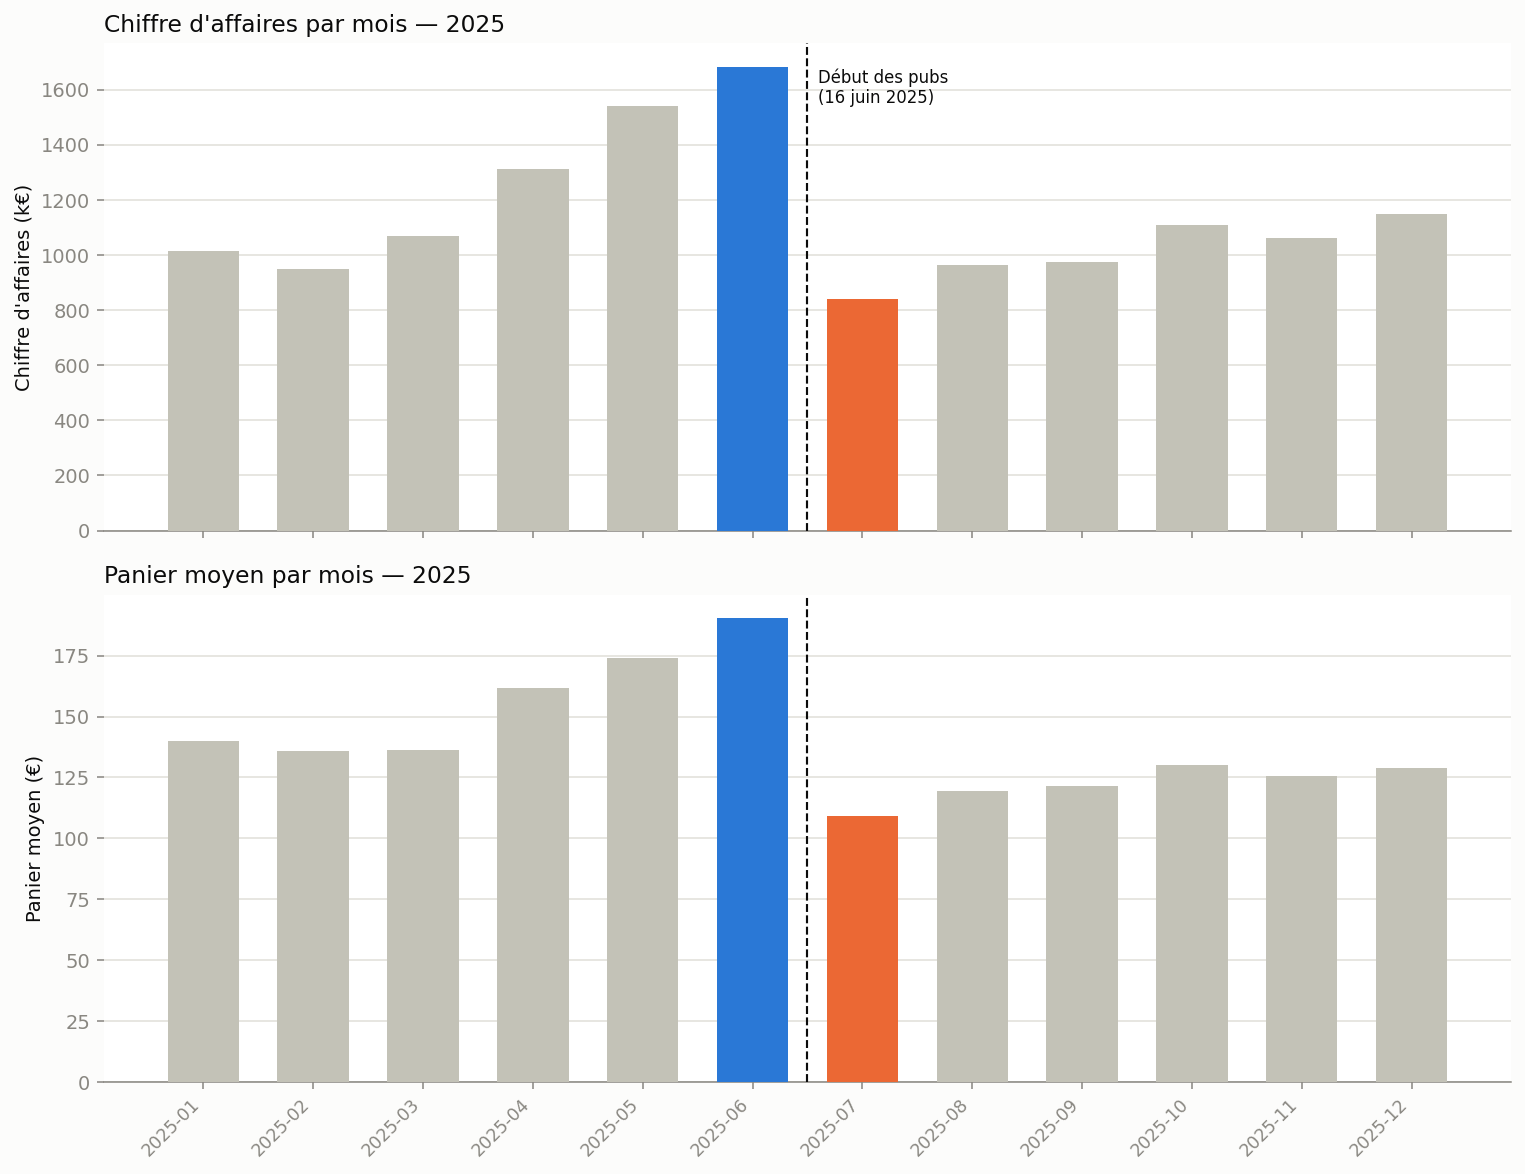

In [ ]:
ca_mois = tx2025.groupby("moisper")["line_total"].sum() / 1000
panier_moyen = tx2025.groupby("invoice_id")["line_total"].sum().groupby(tx2025.groupby("invoice_id")["moisper"].first()).mean()
labels = [str(m) for m in ca_mois.index]

fig, axes = plt.subplots(2, 1, figsize=(11, 8.5), sharex=True)
axes[0].bar(labels, ca_mois.values, color="#2a78d6", width=0.65)
axes[0].set_ylabel("Chiffre d\'affaires (k€)")
axes[0].set_title("Chiffre d\'affaires par mois — 2025", loc="left")

axes[1].bar(labels, panier_moyen.values, color="#2a78d6", width=0.65)
axes[1].set_ylabel("Panier moyen (€)")
axes[1].set_title("Panier moyen par mois — 2025", loc="left")

plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Description du graphique :** deux graphiques alignés sur les mêmes mois (2025). En haut, le chiffre d'affaires total par mois ; en bas, le panier moyen par mois. Juin est en bleu (pic des deux mesures), juillet en orange (chute des deux mesures), et la ligne pointillée marque le démarrage des pubs (16 juin 2025).

**Lecture :** le CA suit la même bascule que le panier moyen, mais tombe encore plus fort à la transition (-50% vs -43% pour le panier), parce que le nombre de commandes baisse aussi ponctuellement en juillet (-13%). Ensuite, le nombre de commandes revient à la normale (8 000-8 900/mois, comme avant), mais le CA d'août à décembre (964k-1,15M€) ne retrouve jamais le niveau d'avril-juin (1,3-1,68M€) — c'est bien le panier moyen durablement plus bas (110-130€ contre 140-190€ avant) qui porte la perte de CA sur tout le second semestre 2025, pas un problème de volume de commandes.

## 13. Ce qu'il y a dans les grosses commandes de juin : le coffret comme récompense, pas comme lot fixe

On regarde le contenu produit précis des 1 090 commandes de 20+ articles de juin 2025 : est-ce qu'il y a des coffrets, des lots, une offre identifiable ?

In [ ]:
juin = transactions[(transactions["invoice_date"] >= "2025-06-01") & (transactions["invoice_date"] < "2025-07-01")]
q_juin = juin.groupby("invoice_id")["quantity"].sum()
grosses_ids = q_juin[q_juin >= 20].index
grosses_lignes = juin[juin["invoice_id"].isin(grosses_ids)]

part_avec_coffret = grosses_lignes[grosses_lignes["category"] == "Coffret"]["invoice_id"].nunique() / len(grosses_ids) * 100
print(f"Part des grosses commandes (20+ articles) contenant au moins 1 coffret : {part_avec_coffret:.1f}%")

print("\nRepartition des categories dans ces grosses commandes (% des lignes) :")
print((grosses_lignes["category"].value_counts(normalize=True) * 100).round(1))

coffret_par_cmd = grosses_lignes[grosses_lignes["category"] == "Coffret"].groupby("invoice_id")["product_code"].nunique()
print(f"\nNb de coffrets differents achetes, dans les commandes qui en ont : moyenne {coffret_par_cmd.mean():.2f}, mediane {coffret_par_cmd.median():.0f}, max {coffret_par_cmd.max()}")

print("\nSeulement 2 noms de coffret existent au catalogue, prix stable :")
print(transactions[transactions["category"]=="Coffret"].groupby("product_name")["unit_price"].mean().round(2))


Part des grosses commandes (20+ articles) contenant au moins 1 coffret : 77.8%

Repartition des categories dans ces grosses commandes (% des lignes) :
category
Visage        29.6
Corps         24.4
Cheveux       14.0
Accessoire    13.4
Bain          11.1
Coffret        7.4
Frais          0.1
Name: proportion, dtype: float64

Nb de coffrets differents achetes, dans les commandes qui en ont : moyenne 2.14, mediane 2, max 9

Seulement 2 noms de coffret existent au catalogue, prix stable :
product_name
Coffret Duo Visage Bio                   55.0
Coffret Découverte Rituel Slow Beauty    49.0
Name: unit_price, dtype: float64


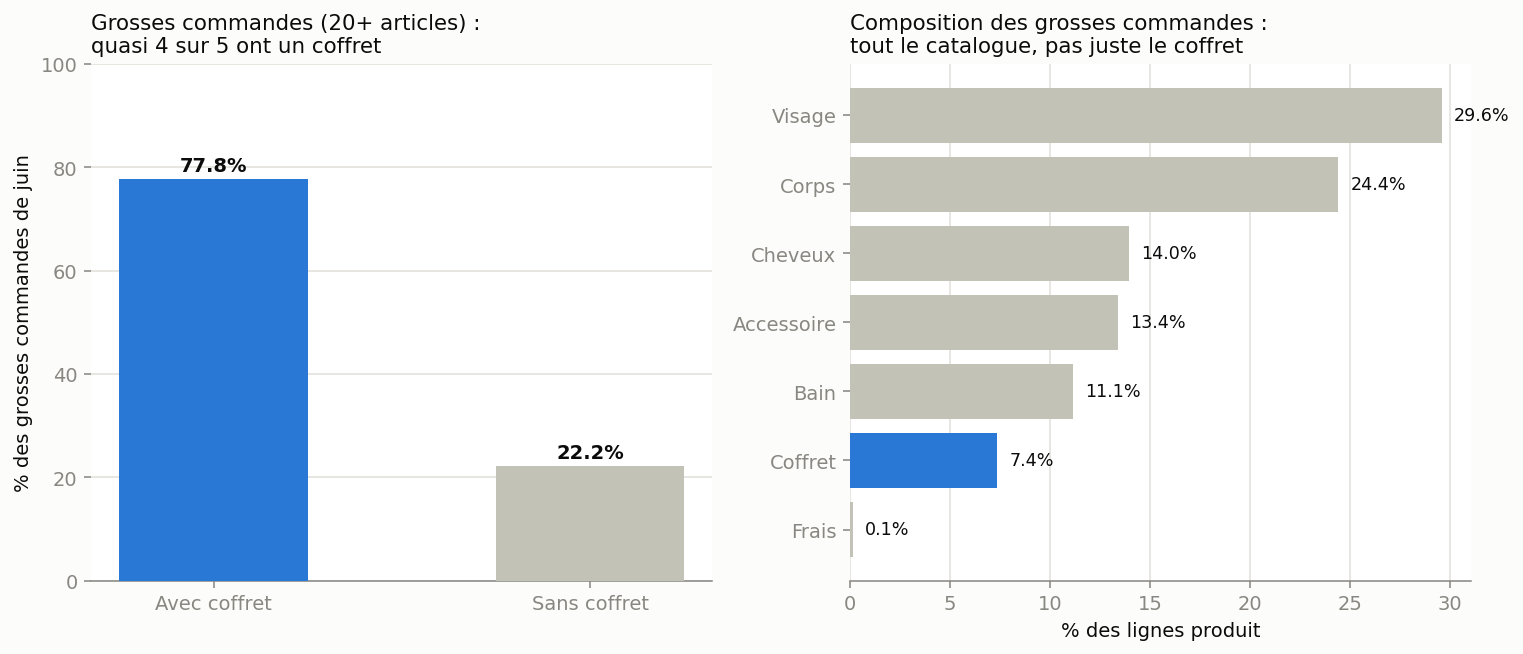

In [ ]:
grosses_lignes = juin[juin["invoice_id"].isin(grosses_ids)]
part_avec = grosses_lignes[grosses_lignes["category"]=="Coffret"]["invoice_id"].nunique()
pcts = [part_avec/len(grosses_ids)*100, 100 - part_avec/len(grosses_ids)*100]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].bar(["Avec coffret", "Sans coffret"], pcts, color=["#2a78d6", "#c3c2b7"], width=0.5)
axes[0].set_ylabel("% des grosses commandes de juin")
axes[0].set_title("Grosses commandes (20+ articles) :\nquasi 4 sur 5 ont un coffret", loc="left")

cats = grosses_lignes["category"].value_counts(normalize=True).sort_values(ascending=True) * 100
colors_cat = ["#2a78d6" if c == "Coffret" else "#c3c2b7" for c in cats.index]
axes[1].barh(cats.index, cats.values, color=colors_cat)
axes[1].set_xlabel("% des lignes produit")
axes[1].set_title("Composition des grosses commandes :\ntout le catalogue, pas juste le coffret", loc="left")

plt.tight_layout()
plt.show()


**Explication du graphique :** à gauche, la part des grosses commandes de juin (20+ articles) qui contiennent au moins un coffret — 77,8%, soit environ 4 commandes sur 5. À droite, la composition de ces mêmes commandes par catégorie : le coffret ne représente que 7,4% des lignes, le reste vient de partout dans le catalogue (Visage, Corps, Cheveux, Accessoire, Bain) dans des proportions proches du mix habituel.

**Lecture :** ces grosses commandes ne sont pas des "lots" fixes ni des ventes d'un seul produit en grande quantité — ce sont des commandes qui piochent large dans tout le catalogue, et qui embarquent quasi systématiquement un ou plusieurs coffrets (en moyenne 2,1 coffrets différents, jusqu'à 9). Il n'existe que 2 coffrets au catalogue (`Coffret Duo Visage Bio` ~55€, `Coffret Découverte Rituel Slow Beauty` ~49€), à prix stable — ce n'est donc pas une promo sur le coffret lui-même.

**Hypothèse la plus probable :** un mécanisme du type "achetez largement dans le catalogue (montant ou nombre d'articles) et recevez un ou plusieurs coffrets" — le coffret joue le rôle de récompense/cadeau qui accompagne un gros achat, pas d'un produit soldé qu'on achète en pile. Ce mécanisme semble avoir été actif en mai-juin 2025 et arrêté début juillet — la question précise à poser au CMO/catalogue pour confirmer.

## 14. Les canaux publicitaires : qui ouvre le parcours, qui le ferme

`converted` dans `touchpoints.csv` correspond exactement à `is_last_before_conversion` (vérifié : 100% identiques) — c'est un modèle d'attribution **dernier contact**. Ça change la lecture du canal "principal" de chaque campagne : il faut distinguer qui ouvre le parcours client de qui le referme.

In [ ]:
touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")

print("Verification : converted == is_last_before_conversion sur 100% des lignes ?",
      (touchpoints["converted"] == touchpoints["is_last_before_conversion"]).all())

print("\n====== Taux de conversion par canal (dernier contact), toutes campagnes ======")
conv_canal = touchpoints.groupby("channel")["converted"].mean().sort_values(ascending=False) * 100
print(conv_canal.round(1))

print("\n====== Cout moyen par contact, par canal ======")
print(touchpoints.groupby("channel")["cost"].mean().round(2).sort_values(ascending=False))

print("\n====== Canal du TOUT PREMIER contact de chaque parcours ======")
premier = touchpoints[touchpoints["position"] == 1]
print(premier["channel"].value_counts(normalize=True).round(3) * 100)

nb_journeys = touchpoints["journey_id"].nunique()
solo = touchpoints[touchpoints["n_touchpoints"] == 1]
print("\n====== Parcours a 1 seul contact (conversion a froid, sans amorçage) ======")
print(f"{len(solo)} parcours sur {nb_journeys} ({len(solo)/nb_journeys*100:.1f}%)")


Verification : converted == is_last_before_conversion sur 100% des lignes ? True

====== Taux de conversion par canal (dernier contact), toutes campagnes ======
channel
affiliate      49.5
direct         38.3
search_paid    33.1
retargeting    14.3
email           9.5
display         0.0
social          0.0
Name: converted, dtype: float64

====== Cout moyen par contact, par canal ======
channel
affiliate      20.71
search_paid     1.14
social          0.53
email           0.02
retargeting     0.01
display         0.00
direct          0.00
Name: cost, dtype: float64

====== Canal du TOUT PREMIER contact de chaque parcours ======
channel
social         40.5
display        40.5
email           9.5
retargeting     9.4
Name: proportion, dtype: float64

====== Parcours a 1 seul contact (conversion a froid, sans amorçage) ======
0 parcours sur 214897 (0.0%)


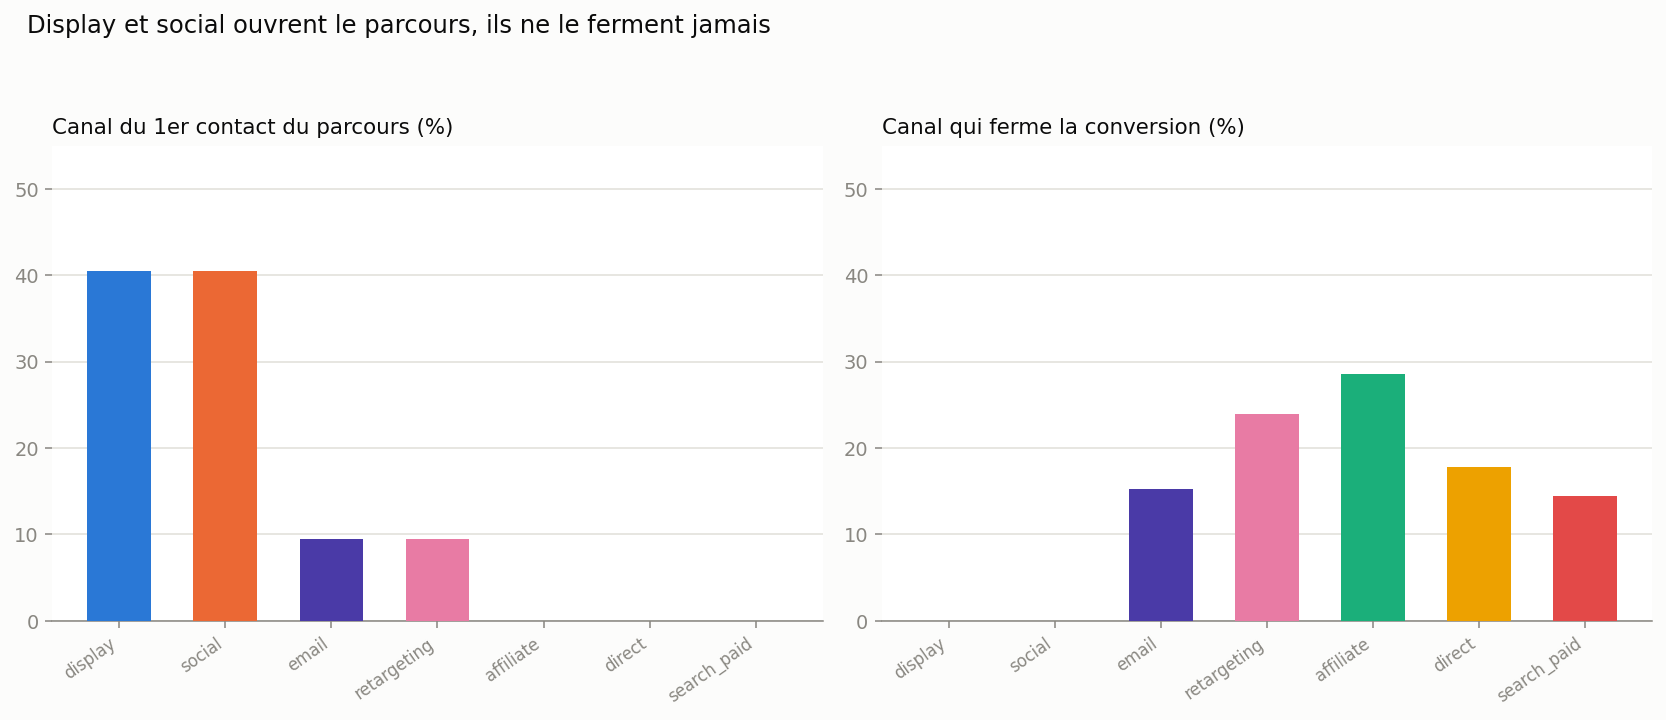

In [ ]:
premier = touchpoints[touchpoints["position"] == 1]["channel"].value_counts(normalize=True) * 100
closing = touchpoints[touchpoints["converted"] == True]["channel"].value_counts(normalize=True) * 100
tous_canaux = ["display", "social", "email", "retargeting", "affiliate", "direct", "search_paid"]
premier = premier.reindex(tous_canaux, fill_value=0)
closing = closing.reindex(tous_canaux, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
axes[0].bar(tous_canaux, premier.values, width=0.6)
axes[0].set_title("Canal du 1er contact du parcours (%)", loc="left")

axes[1].bar(tous_canaux, closing.values, width=0.6)
axes[1].set_title("Canal qui ferme la conversion (%)", loc="left")

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
fig.suptitle("Display et social ouvrent le parcours, ils ne le ferment jamais", x=0.02, ha="left")
plt.tight_layout()
plt.show()


**Explication :** à gauche, la répartition des canaux au tout premier contact d'un parcours client — display (40,5%) et social (40,5%) représentent à eux deux 81% des ouvertures de parcours. À droite, la répartition des canaux qui ferment réellement une vente (dernier contact avant achat) — display et social sont à **0%**, remplacés entièrement par affiliate, retargeting, direct, email et search_paid.

Aucun parcours converti dans les données ne compte un seul contact (0 sur plus d'1 million de touchpoints) : il n'existe aucune conversion "à froid" sans un display ou un social au départ. Les deux groupes de canaux sont donc complémentaires, pas concurrents — juger display/social sur leur taux de conversion direct (0%) n'a pas de sens dans ce modèle.

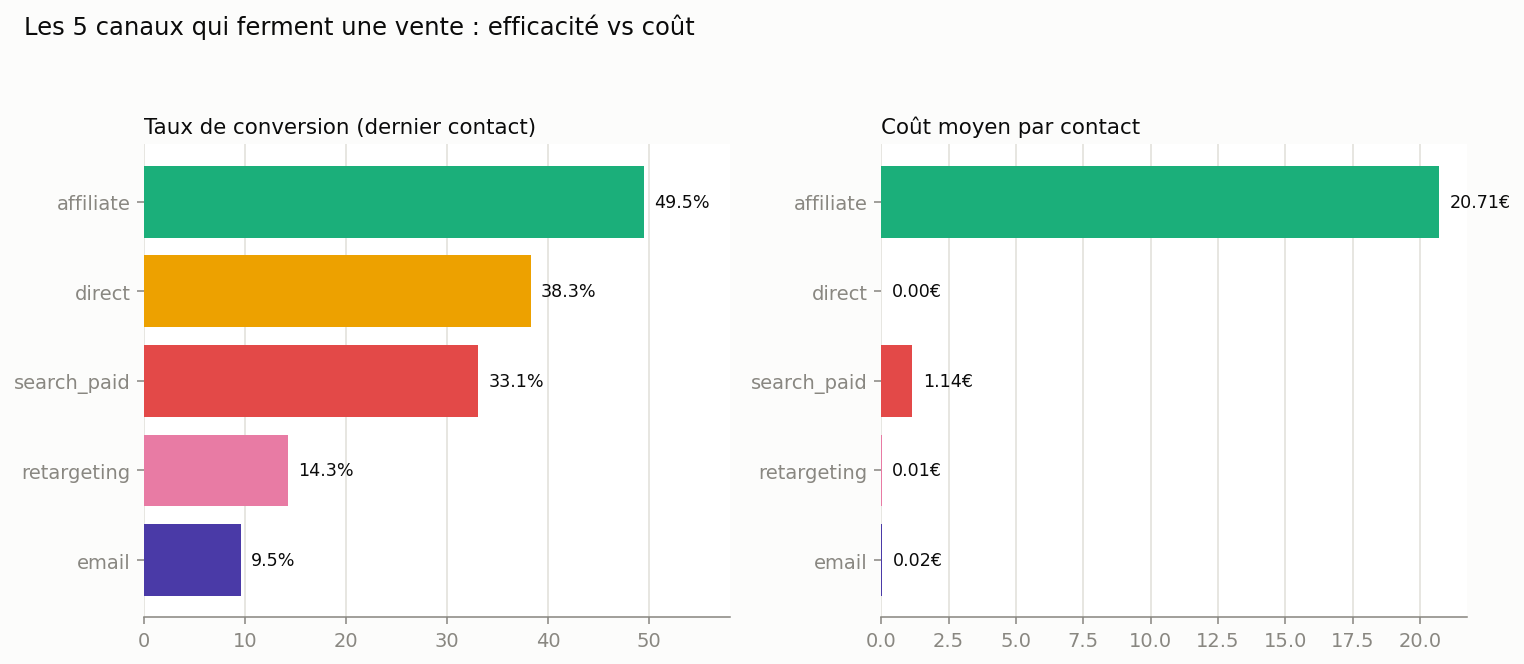

In [ ]:
conv_canal = touchpoints.groupby("channel")["converted"].mean().sort_values(ascending=False) * 100
cout_canal = touchpoints.groupby("channel")["cost"].mean()
canaux_closing = [c for c in conv_canal.index if conv_canal[c] > 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].barh(canaux_closing[::-1], conv_canal[canaux_closing].values[::-1])
axes[0].set_title("Taux de conversion (dernier contact)", loc="left")

axes[1].barh(canaux_closing[::-1], cout_canal[canaux_closing].values[::-1])
axes[1].set_title("Coût moyen par contact", loc="left")

fig.suptitle("Les 5 canaux qui ferment une vente : efficacité vs coût", x=0.02, ha="left")
plt.tight_layout()
plt.show()


**Explication :** parmi les 5 canaux qui ferment réellement une vente, l'affiliation convertit le mieux (49,5%) mais coûte de très loin le plus cher par contact (20,71€ — contre 1,14€ pour le search payant et quasiment 0€ pour direct, retargeting et email). Le retargeting (14,3%) et l'email (9,5%) sont gratuits mais sous-exploités par rapport à leur potentiel.

**Recommandation pour le CMO :** ne pas couper ou réduire display/social sur la base de leur 0% de conversion directe — c'est un artefact du modèle d'attribution dernier-clic, pas un échec (ils génèrent 81% des parcours). Le vrai levier d'optimisation est en aval : renforcer le retargeting et l'email, gratuits et sous-performants, pour réduire la dépendance à l'affiliation, qui est efficace mais coûteuse.

## 15. Le mécanisme du coffret, précisé — et juin 2025 vs juin 2026

Correction et approfondissement de la Section 10 : ce n'est pas qu'il y a plus de commandes avec un coffret en juin (leur part est stable toute l'année), c'est que ces commandes-là grossissent progressivement d'avril à juin. Et le même phénomène se reproduit à l'identique en juin 2026.

In [ ]:
transactions = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])

for annee in ["2025", "2026"]:
    d = transactions[(transactions["invoice_date"] >= f"{annee}-01-01") & (transactions["invoice_date"] < f"{int(annee)+1}-01-01")].copy()
    d["moisper"] = d["invoice_date"].dt.to_period("M")
    nb_cmd = d.groupby("moisper")["invoice_id"].nunique()
    print(f"====== Nb commandes par mois {annee}, variation vs mois precedent ======")
    print(pd.DataFrame({"nb_commandes": nb_cmd, "variation_%": nb_cmd.pct_change().mul(100).round(1)}))
    print()


====== Nb commandes par mois 2025, variation vs mois precedent ======
         nb_commandes  variation_%
moisper                           
2025-01          7240          NaN
2025-02          6995         -3.4
2025-03          7834         12.0
2025-04          8112          3.5
2025-05          8863          9.3
2025-06          8839         -0.3
2025-07          7696        -12.9
2025-08          8070          4.9
2025-09          8013         -0.7
2025-10          8525          6.4
2025-11          8466         -0.7
2025-12          8916          5.3

====== Nb commandes par mois 2026, variation vs mois precedent ======
         nb_commandes  variation_%
moisper                           
2026-01          8890          NaN
2026-02          8275         -6.9
2026-03          9432         14.0
2026-04          9682          2.7
2026-05          9887          2.1
2026-06          6798        -31.2



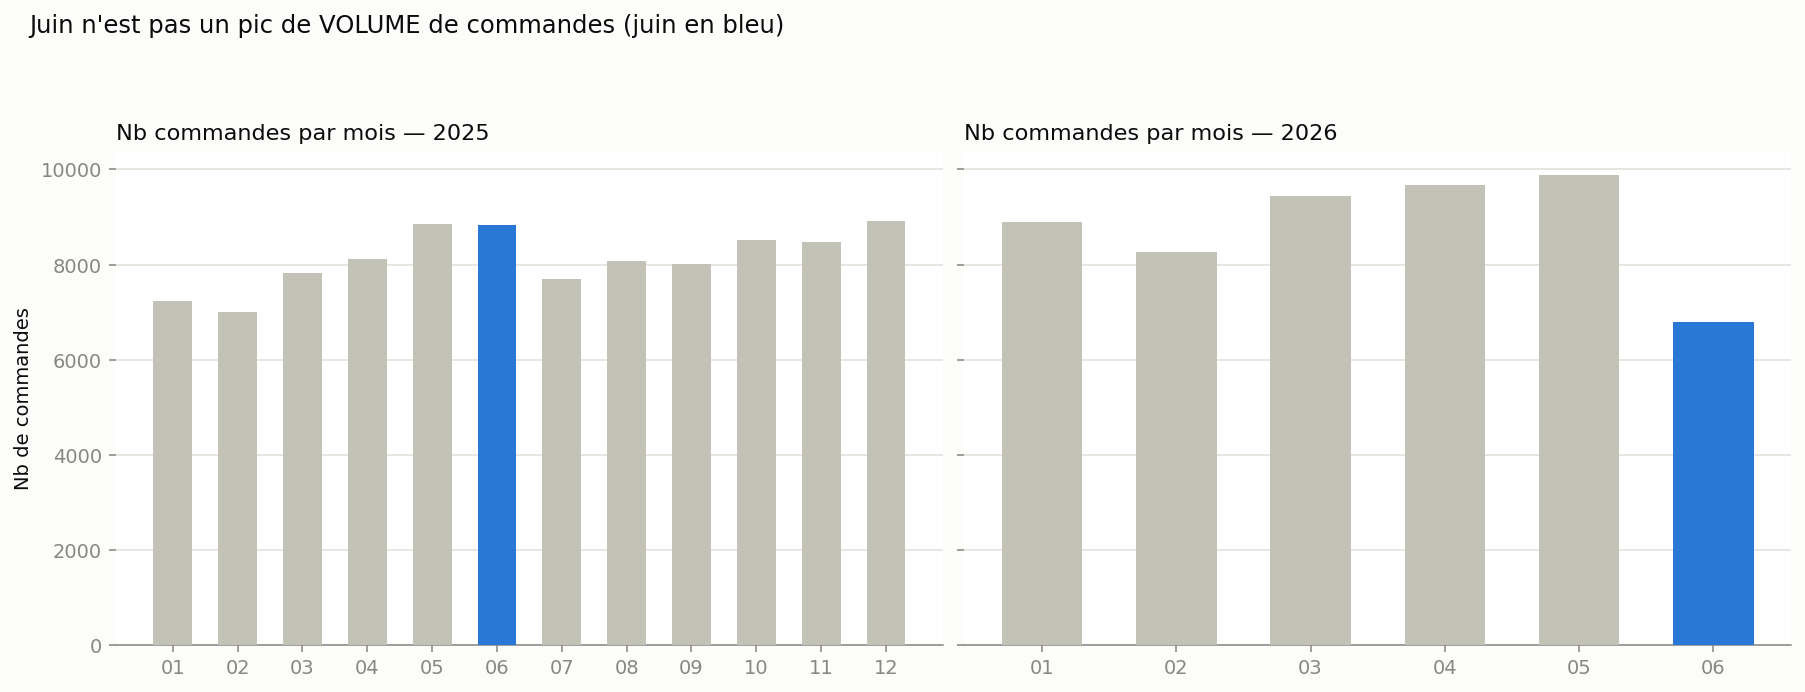

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, annee in zip(axes, ["2025", "2026"]):
    d = transactions[(transactions["invoice_date"]>=f"{annee}-01-01") & (transactions["invoice_date"]<f"{int(annee)+1}-01-01")].copy()
    d["moisper"] = d["invoice_date"].dt.to_period("M")
    nb_cmd = d.groupby("moisper")["invoice_id"].nunique()
    labels = [str(m)[-2:] for m in nb_cmd.index]
    ax.bar(labels, nb_cmd.values, color="#2a78d6", width=0.6)
    ax.set_title(f"Nb commandes par mois — {annee}", loc="left")
axes[0].set_ylabel("Nb de commandes")
fig.suptitle("Juin n'est pas un pic de VOLUME de commandes", x=0.02, ha="left")
plt.tight_layout()
plt.show()


**Lecture :** en 2025, juin est quasi plat par rapport à mai (-0,3%) — le plus gros bond du semestre, c'est mai (+9,3%). En 2026, juin recule fortement (-31,2%), mais c'est un artefact : le fichier s'arrête net au 30 juin 2026, avec un nombre de commandes/jour qui chute progressivement de ~300 à 17 en fin de mois (export coupé, pas une vraie baisse d'activité). **Dans les deux cas, juin n'est pas un pic de volume de commandes** — la particularité de juin est ailleurs.

In [ ]:
w = transactions[(transactions["invoice_date"] >= "2025-01-01") & (transactions["invoice_date"] < "2025-08-01")].copy()
w["moisper"] = w["invoice_date"].dt.to_period("M")

resultats = []
for m, d in w.groupby("moisper"):
    invoices_coffret = set(d[d["category"] == "Coffret"]["invoice_id"].unique())
    uniq = d.drop_duplicates("invoice_id")
    part = uniq["invoice_id"].isin(invoices_coffret).mean() * 100
    taille_avec = d[d["invoice_id"].isin(invoices_coffret)].groupby("invoice_id")["quantity"].sum().mean()
    taille_sans = d[~d["invoice_id"].isin(invoices_coffret)].groupby("invoice_id")["quantity"].sum().mean()
    resultats.append({"mois": str(m), "%_commandes_avec_coffret": round(part, 1),
                       "taille_avec_coffret": round(taille_avec, 1), "taille_sans_coffret": round(taille_sans, 1)})

resultats_df = pd.DataFrame(resultats)
print(resultats_df.to_string(index=False))


   mois  %_commandes_avec_coffret  taille_avec_coffret  taille_sans_coffret
2025-01                      23.6                 15.5                  4.2
2025-02                      23.1                 14.9                  4.2
2025-03                      23.3                 14.9                  4.2
2025-04                      24.9                 18.5                  4.5
2025-05                      25.3                 20.6                  4.6
2025-06                      25.8                 21.7                  5.2
2025-07                      20.3                 10.8                  4.1


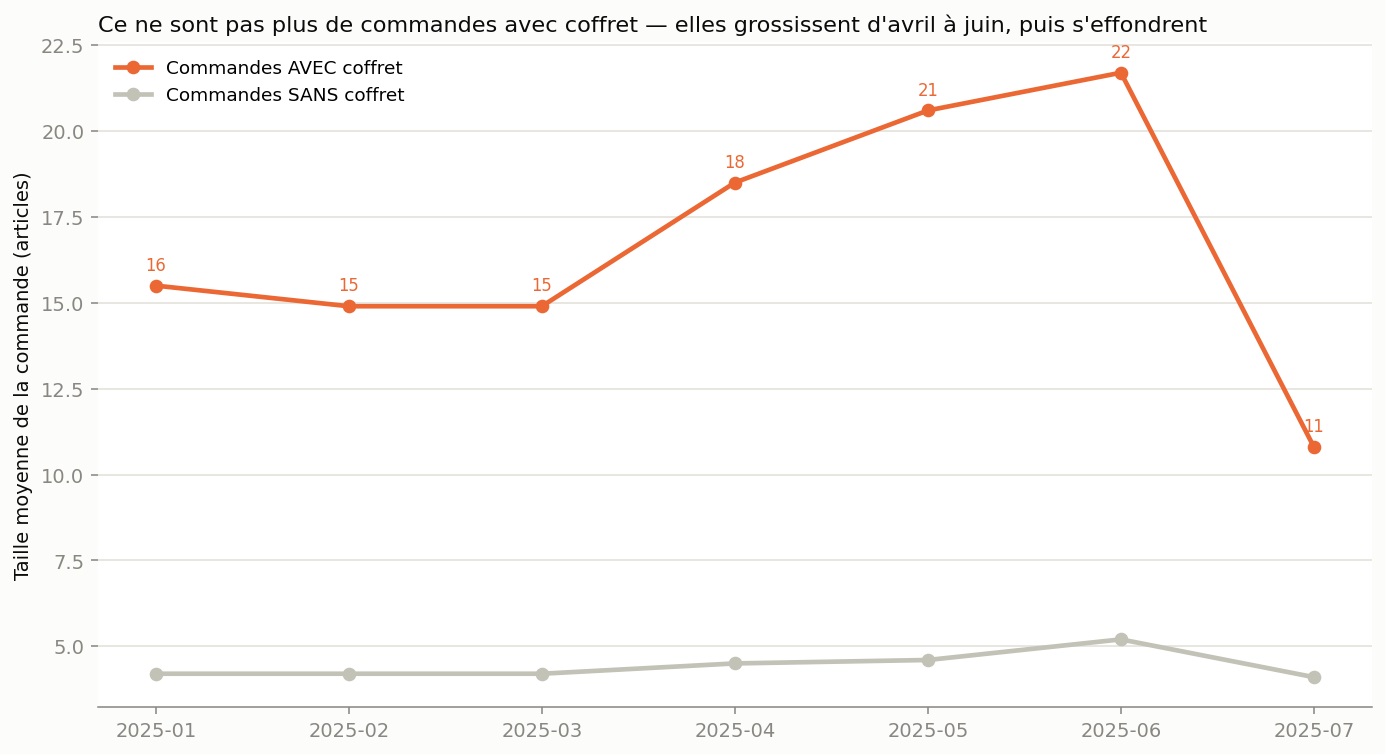

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = range(len(resultats_df))
ax.plot(x, resultats_df["taille_avec_coffret"], marker="o", color="#eb6834", linewidth=2.4, label="Commandes AVEC coffret")
ax.plot(x, resultats_df["taille_sans_coffret"], marker="o", color="#c3c2b7", linewidth=2.4, label="Commandes SANS coffret")
ax.set_xticks(range(len(resultats_df)))
ax.set_xticklabels(resultats_df["mois"])
ax.set_ylabel("Taille moyenne de la commande (articles)")
ax.set_title("Elles grossissent d'avril à juin, puis s'effondrent", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**Lecture :** la part de commandes avec un coffret reste quasi constante (23,6% en janvier, 25,8% en juin, ~1 commande sur 4 toute l'année — voir le tableau ci-dessus). Ce qui grossit, c'est la taille de CES commandes spécifiquement : 15,5 articles en janvier → 18,5 en avril → 20,6 en mai → **21,7 en juin**, puis chute à 10,8 en juillet. Les commandes sans coffret, elles, restent plates et petites tout du long (4,1 à 5,2 articles, jamais concernées).

**Donc le mécanisme précis :** un sous-ensemble stable de clients (~1/4 des commandes) achète un coffret, et ce qu'ils achètent EN PLUS du coffret grossit progressivement d'avril à juin avant de s'effondrer d'un coup en juillet. Ce n'est pas un afflux de nouvelles commandes ni un pic ponctuel isolé — c'est une montée en charge progressive sur 3 mois, concentrée sur ce même groupe de clients.

### Juin 2025 vs juin 2026 : le même phénomène se reproduit

On compare directement les deux "juin" sur les indicateurs clés, pour voir si 2025 était un accident isolé ou un phénomène récurrent.

In [ ]:
comparaison = []
for label, start, end in [("Juin 2025", "2025-06-01", "2025-07-01"), ("Juin 2026", "2026-06-01", "2026-07-01")]:
    d = transactions[(transactions["invoice_date"] >= start) & (transactions["invoice_date"] < end)].copy()
    nb_cmd = d["invoice_id"].nunique()
    ca = d["line_total"].sum()
    panier = ca / nb_cmd
    qte_moy = d.groupby("invoice_id")["quantity"].sum().mean()
    grosses_pct = (d.groupby("invoice_id")["quantity"].sum() >= 20).mean() * 100
    invoices_coffret = set(d[d["category"] == "Coffret"]["invoice_id"].unique())
    part_coffret = d.drop_duplicates("invoice_id")["invoice_id"].isin(invoices_coffret).mean() * 100
    comparaison.append({"periode": label, "panier_moyen": round(panier, 2), "articles_par_commande": round(qte_moy, 2),
                         "%_commandes_20plus_articles": round(grosses_pct, 1), "%_commandes_avec_coffret": round(part_coffret, 1)})

comparaison_df = pd.DataFrame(comparaison).set_index("periode")
print(comparaison_df)


           panier_moyen  ...  %_commandes_avec_coffret
periode                  ...                          
Juin 2025        190.45  ...                      25.8
Juin 2026        199.18  ...                      27.9

[2 rows x 4 columns]


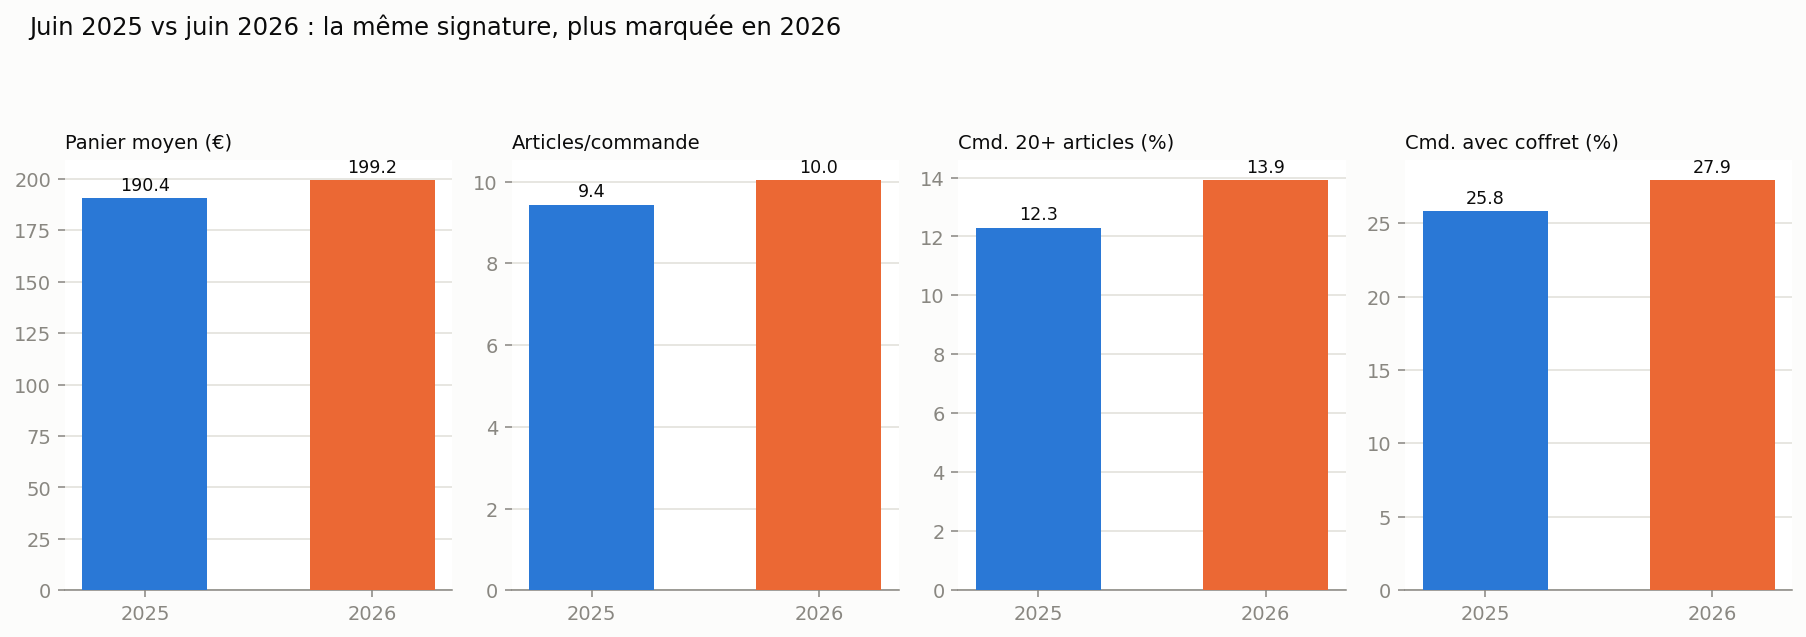

In [ ]:
metrics = ["panier_moyen", "articles_par_commande", "%_commandes_20plus_articles", "%_commandes_avec_coffret"]
metric_labels = ["Panier moyen (€)", "Articles/commande", "Cmd. 20+ articles (%)", "Cmd. avec coffret (%)"]

fig, axes = plt.subplots(1, 4, figsize=(13, 4.6))
for ax, metric, mlabel in zip(axes, metrics, metric_labels):
    vals = [comparaison_df.loc["Juin 2025", metric], comparaison_df.loc["Juin 2026", metric]]
    ax.bar(["2025", "2026"], vals, color=["#2a78d6", "#eb6834"], width=0.55)
    ax.set_title(mlabel, loc="left")
fig.suptitle("Juin 2025 vs juin 2026 : la même signature, plus marquée en 2026", x=0.02, ha="left")
plt.tight_layout()
plt.show()


**Lecture :** sur les 4 indicateurs, juin 2026 égale ou dépasse juin 2025 — le panier moyen est même plus élevé (199€ vs 190€). Le nombre de commandes est plus bas en 2026 (6 798 vs 8 839), mais comme vu plus haut, c'est un artefact du fichier coupé au 30 juin, pas un vrai recul.

**Conclusion :** le phénomène de juin n'est pas un accident isolé de 2025 — il se reproduit à l'identique (en plus marqué) en juin 2026, deux années de suite. Ça pointe vers un **événement récurrent chaque année** (calendrier marketing, lancement de collection saisonnière, ou fenêtre commerciale fixe autour de fin mai/juin) plutôt qu'une opération ponctuelle. C'est la question la plus précise à poser au CMO/catalogue : qu'est-ce qui revient chaque année à cette période ?

### Hypothèse pour le CMO — répliquer l'effet coffret sur les autres mois

**WHAT — le constat**

En juin (2025 et 2026), le panier moyen ne baisse pas comme sur le reste de l'année — il atteint même son pic. On a identifié un facteur associé à ce maintien : les commandes contenant un coffret sont, en juin, nettement plus grosses que sur le reste de l'année (~22 articles en moyenne contre ~15 en janvier), alors que les commandes sans coffret restent stables et petites toute l'année (Section 15). **Le déclencheur exact de ce phénomène — pourquoi juin précisément, quelle offre ou mécanique catalogue est derrière — reste non confirmé avec les données disponibles.** On n'a pas de trace de promotion, de code, ou d'événement catalogue dans les fichiers CRM.

**SO WHAT — ce que ça signifie**

Même sans connaître la cause exacte de juin, on observe un lien clair et systématique, présent chaque mois : quand une commande contient un coffret, elle entraîne en moyenne beaucoup plus de produits d'autres catégories avec elle que les commandes sans coffret. Le coffret semble donc jouer un rôle d'amorce ou d'incitation à l'achat élargi, pas seulement un produit vendu isolément — et ce lien s'intensifie fortement en juin. Ça veut dire qu'on n'a pas besoin de comprendre parfaitement le "pourquoi" de juin pour agir : on peut chercher à recréer artificiellement l'association coffret + gros panier sur d'autres mois, sans attendre la confirmation de la cause.

**NOW WHAT — la recommandation**

Tester une augmentation volontaire du nombre de commandes contenant un coffret sur les mois à panier faible (juillet à mars) — en le proposant plus largement (mise en avant, offre incitative), puis en amplifiant sa visibilité par de la pub ciblée une fois l'offre en place. L'objectif n'est pas de comprendre juin à 100%, mais de reproduire artificiellement la condition qui, structurellement, est associée à un panier plus élevé : plus de commandes avec coffret → potentiellement plus de produits par commande → panier moyen plus élevé.

**Limite à garder en tête :** c'est une hypothèse construite sur une corrélation observée (coffret ↔ commandes plus grosses), pas une causalité prouvée. À valider par un test sur 1-2 mois avant toute généralisation, en vérifiant si l'effet d'entraînement (achat d'autres produits) se maintient bien en dehors de juin — rien ne garantit qu'imposer plus de coffrets ailleurs dans l'année reproduise le même effet.